# 수익률 예측 MSE

In [1]:
import pandas as pd
import numpy as np

# 1. 시퀀스 데이터 불러오기 (기존 특성 데이터)
seq_file_path = './processed_sequences/train_data_seq_30d.csv'
df = pd.read_csv(seq_file_path)

# 날짜 타입 통일
df['target_date'] = pd.to_datetime(df['target_date'])

# 2. 실제 수익률 데이터 불러오기 (Regression의 새로운 정답지)
returns_file_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)

# 3. 수익률 데이터를 병합하기 좋게 세로형(Long format)으로 변환
returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 4. 기존 데이터프레임에 실제 수익률 매핑 (Left Join)
merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')

# 혹시 모를 결측치 처리 (수익률이 없는 날짜)
initial_len = len(merged_df)
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)
dropped_len = initial_len - len(merged_df)

print(f"데이터 병합 완료!")
print(f" - 총 데이터 개수: {len(merged_df)}개 (결측치로 제거된 데이터: {dropped_len}개)")
print("\n[병합된 데이터 핵심 컬럼 미리보기]")
# 기존의 target(0,1) 옆에 새로운 정답지인 actual_target_return(소수점 수익률)이 붙었는지 확인합니다.
display(merged_df[['target_date', 'ticker', 'split_id', 'dataset_type', 'target', 'actual_target_return']].head())

데이터 병합 완료!
 - 총 데이터 개수: 208080개 (결측치로 제거된 데이터: 0개)

[병합된 데이터 핵심 컬럼 미리보기]


,target_date,ticker,split_id,dataset_type,target,actual_target_return
0,2021-05-09,NVDA,1,Train,1,0.000000
1,2021-05-10,NVDA,1,Train,0,-0.036895
2,2021-05-11,NVDA,1,Train,1,0.002839
3,2021-05-12,NVDA,1,Train,0,-0.038287
4,2021-05-13,NVDA,1,Train,0,-0.006777


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. 시퀀스 데이터 컬럼 정의 (30일치)
seq_length = 30
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]

# 2. 첫 번째 Split 데이터만 임시로 분리 (구조 테스트용)
target_split = 1
split_df = merged_df[merged_df['split_id'] == target_split]

train_df = split_df[split_df['dataset_type'] == 'Train']
test_df = split_df[split_df['dataset_type'] == 'Test']

# 3. PyTorch 텐서 변환 
# ( 핵심 변경 사항: 정답지 y를 target(0,1)이 아니라 actual_target_return(연속형 실수)으로 매핑합니다!)
X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(train_df['actual_target_return'].values, dtype=torch.float32).unsqueeze(-1)

X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(test_df['actual_target_return'].values, dtype=torch.float32).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

# 4. 회귀(Regression)용 LSTM 모델로 전면 개편
class RegressionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(RegressionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # PyTorch 최적화 내장 LSTM 사용 (기존 커스텀 Cell 대비 연산 속도 대폭 증가)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.1)
        
        # 최종 출력은 1개 (하회/상회 확률 2개가 아니라, '예측된 수익률' 단일 값!)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x.shape = (batch_size, seq_length, input_size)
        lstm_out, _ = self.lstm(x)
        
        # 마지막 30일차(t 시점)의 은닉 상태(hidden state)만 가져옴
        last_time_step_out = lstm_out[:, -1, :] 
        
        out = self.dropout(last_time_step_out)
        
        # Softmax 없이 그냥 선형(Linear) 계층 통과 (회귀 분석이므로 그대로 출력)
        out = self.fc(out) 
        return out

# 모델 객체 생성 및 테스트
model = RegressionLSTM(input_size=1, hidden_size=25)
model.eval()

# 가짜 데이터로 모델 출력 형태가 맞는지 최종 확인
dummy_input = torch.randn(5, 30, 1) # 5개 배치, 30일 시퀀스, 1개 피처
with torch.no_grad():
    sample_output = model(dummy_input)

print("데이터 텐서 변환 및 회귀(Regression) 모델 구축 완료!")
print(f" - Train X 텐서 크기: {X_train_tensor.shape}")
print(f" - Train y 텐서 크기: {y_train_tensor.shape} (정답 데이터가 연속형 실수 1개로 변경됨)")
print("\n[모델 테스트 출력 (5개 샘플에 대한 예상 수익률 결과)]")
print(sample_output)
print("-> 출력값이 0~1 사이의 2개 확률(확률)이 아니라, [±수익률] 1개 값으로 잘 나옵니다!")

데이터 텐서 변환 및 회귀(Regression) 모델 구축 완료!
 - Train X 텐서 크기: torch.Size([17040, 30, 1])
 - Train y 텐서 크기: torch.Size([17040, 1]) (정답 데이터가 연속형 실수 1개로 변경됨)

[모델 테스트 출력 (5개 샘플에 대한 예상 수익률 결과)]
tensor([[0.0414],
        [0.0534],
        [0.0538],
        [0.0445],
        [0.0530]])
-> 출력값이 0~1 사이의 2개 확률(확률)이 아니라, [±수익률] 1개 값으로 잘 나옵니다!


In [3]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 학습 세팅 (분류용 CrossEntropy 대신 회귀용 MSELoss 사용)
num_epochs = 30 # 빠른 구조 테스트를 위해 30번만 수행
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []

print(f"[Split {target_split}] 회귀 모델 학습 시작...")

# 2. 모델 학습 (Train)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 너무 길지 않게 5 에포크마다 출력
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train MSE Loss: {avg_loss:.6f}")

# 3. 모델 평가 및 예측 수익률 산출 (Test)
model.eval()
all_preds = []

print("\n[테스트 데이터 예측 및 포트폴리오 로직 적용]")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        # [batch_size, 1] 형태의 2차원 배열을 1차원으로 쫙 폅니다
        all_preds.extend(outputs.cpu().numpy().flatten()) 

# 원본 테스트 데이터프레임에 예측 수익률 매핑
test_df = test_df.copy()
test_df['predicted_return'] = all_preds

# 4. 교수님 지시사항 적용: 조건부 롱/숏 포트폴리오 구성
portfolio_list = []

for date, daily_data in test_df.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 예측 수익률(predicted_return) 기준으로 내림차순 정렬 (1등부터 꼴등까지)
    sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
    
    # [조건 1] 상위 5개를 선정하되, 예측 수익률이 0보다 큰(+) 경우만 Long
    top_5 = sorted_data.head(5).copy()
    long_stocks = top_5[top_5['predicted_return'] > 0].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list.append(long_stocks)
        
    # [조건 2] 하위 5개를 선정하되, 예측 수익률이 0보다 작은(-) 경우만 Short
    bottom_5 = sorted_data.tail(5).copy()
    short_stocks = bottom_5[bottom_5['predicted_return'] < 0].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list.append(short_stocks)

# 비어있는 날짜를 대비해 데이터 병합
if portfolio_list:
    final_portfolio = pd.concat(portfolio_list).reset_index(drop=True)
else:
    final_portfolio = pd.DataFrame()

print("새로운 조건의 포트폴리오 구성\n")
print("-" * 50)
print("[결과 확인] 첫 번째 날짜의 거래 포지션 (0 초과 매수, 0 미만 공매도):")
if not final_portfolio.empty:
    sample_date = final_portfolio['target_date'].unique()[0]
    result_display = final_portfolio[final_portfolio['target_date'] == sample_date][['target_date', 'ticker', 'predicted_return', 'actual_target_return', 'position']]
    display(result_display)
    print("-" * 50)
    print(f"테스트 기간 동안 선정된 전체 포지션 개수: {len(final_portfolio)}개")
    print("(과거와 달리 무조건 10개를 꽉 채우지 않고, 조건 미달 시 거래를 쉬게 됩니다!)")
else:
    print("해당 Split에서는 포지션 진입 조건을 만족하는 종목이 없습니다.")

[Split 1] 회귀 모델 학습 시작...
Epoch [1/30] Train MSE Loss: 0.001550
Epoch [5/30] Train MSE Loss: 0.001015
Epoch [10/30] Train MSE Loss: 0.000948
Epoch [15/30] Train MSE Loss: 0.000909
Epoch [20/30] Train MSE Loss: 0.000908
Epoch [25/30] Train MSE Loss: 0.000902
Epoch [30/30] Train MSE Loss: 0.000901

[테스트 데이터 예측 및 포트폴리오 로직 적용]
새로운 조건의 포트폴리오 구성

--------------------------------------------------
[결과 확인] 첫 번째 날짜의 거래 포지션 (0 초과 매수, 0 미만 공매도):


,target_date,ticker,predicted_return,actual_target_return,position
0,2022-07-09,PG,0.001924,0.000000,Long
1,2022-07-09,USDC-USD,0.001650,0.000268,Long
2,2022-07-09,DOGE-USD,0.001486,0.003682,Long
3,2022-07-09,JNJ,0.001473,0.000000,Long
4,2022-07-09,ADA-USD,0.001437,0.024500,Long
5,2022-07-09,CAT,-0.000735,0.000000,Short


--------------------------------------------------
테스트 기간 동안 선정된 전체 포지션 개수: 1185개
(과거와 달리 무조건 10개를 꽉 채우지 않고, 조건 미달 시 거래를 쉬게 됩니다!)


전체 구간(All Splits) 롤링 윈도우 백테스트

--- [Split 1] 학습 및 예측 진행 중 ---
--- [Split 2] 학습 및 예측 진행 중 ---
--- [Split 3] 학습 및 예측 진행 중 ---
--- [Split 4] 학습 및 예측 진행 중 ---
--- [Split 5] 학습 및 예측 진행 중 ---
--- [Split 6] 학습 및 예측 진행 중 ---
--- [Split 7] 학습 및 예측 진행 중 ---
--- [Split 8] 학습 및 예측 진행 중 ---
--- [Split 9] 학습 및 예측 진행 중 ---


c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


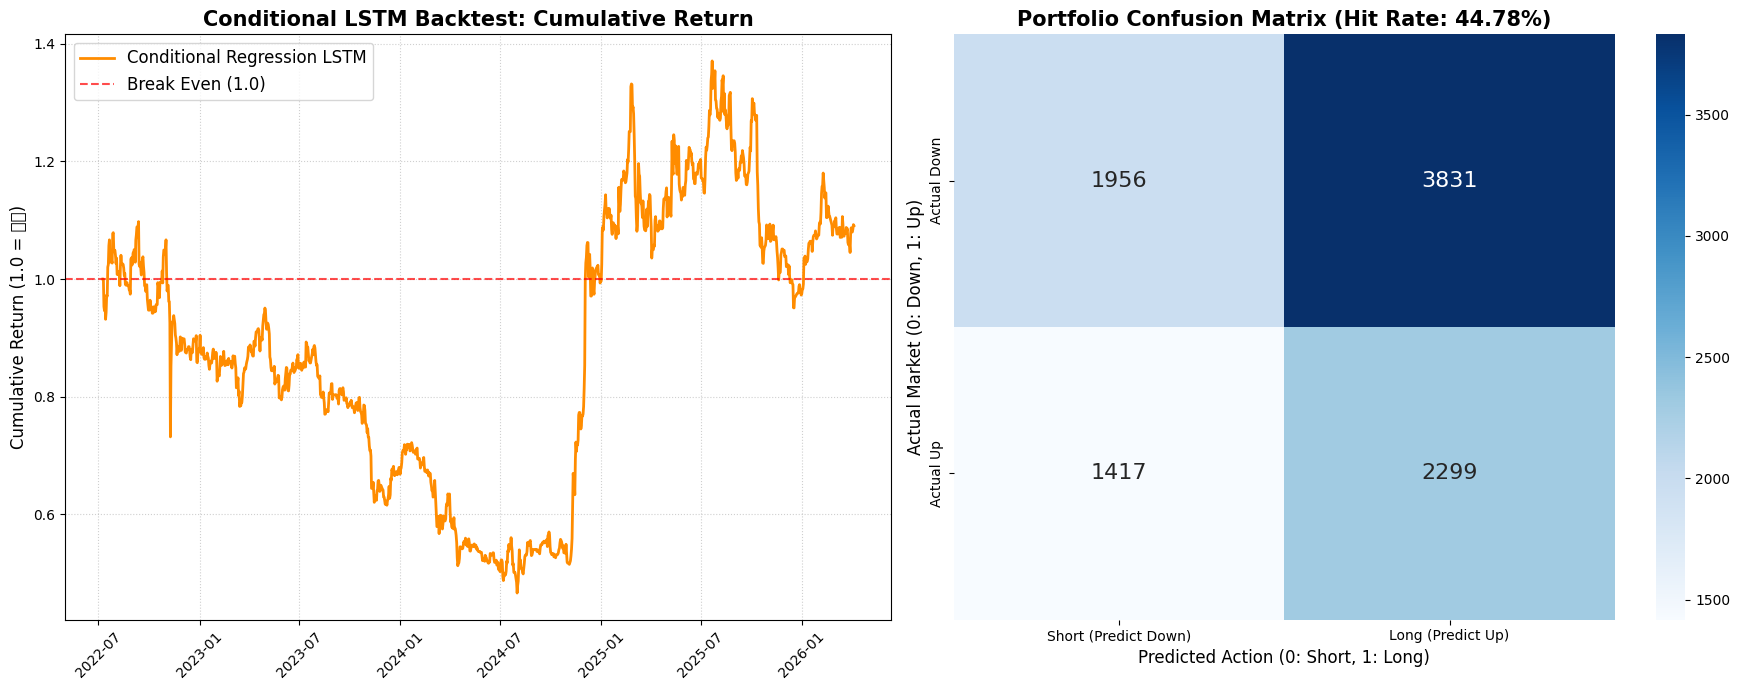

[최종 백테스트 리포트]
총 거래(포지션 진입) 횟수: 9503 건
롱(Long) 진입 횟수: 6130 건
숏(Short) 진입 횟수: 3373 건
포트폴리오 적중률(Hit Rate): 44.78%


In [4]:
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import confusion_matrix, accuracy_score

print("전체 구간(All Splits) 롤링 윈도우 백테스트\n")

all_portfolios = []
all_test_results = [] # 혼동행렬을 위한 전체 테스트 데이터 예측값 저장

num_epochs = 30
unique_splits = sorted(merged_df['split_id'].unique())

for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 예측 진행 중 ---")
    
    # 1. 데이터 분리 및 텐서 변환
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue 
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['actual_target_return'].values, dtype=torch.float32).unsqueeze(-1)
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test = torch.tensor(test_df['actual_target_return'].values, dtype=torch.float32).unsqueeze(-1)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
    
    # 2. 모델 초기화 및 학습 (회귀 모델 & MSE)
    model = RegressionLSTM(input_size=1, hidden_size=25)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # 3. 모델 평가 및 예측
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            all_preds.extend(model(batch_X).cpu().numpy().flatten())

    test_df = test_df.copy()
    test_df['predicted_return'] = all_preds
    all_test_results.append(test_df) # 전체 성능 평가용
    
    # 4. 조건부 롱/숏 포트폴리오 구성 (교수님 지시사항)
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10:
            continue
            
        sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
        
        # 상위 5개 중 +일 때만 Long
        long_stocks = sorted_data.head(5).copy()
        long_stocks = long_stocks[long_stocks['predicted_return'] > 0]
        if not long_stocks.empty:
            long_stocks['position'] = 'Long'
            portfolio_list.append(long_stocks)
            
        # 하위 5개 중 -일 때만 Short
        short_stocks = sorted_data.tail(5).copy()
        short_stocks = short_stocks[short_stocks['predicted_return'] < 0]
        if not short_stocks.empty:
            short_stocks['position'] = 'Short'
            portfolio_list.append(short_stocks)
            
    if portfolio_list:
        all_portfolios.append(pd.concat(portfolio_list))

# ---------------------------------------------------------
# [결과 산출 및 시각화]
# ---------------------------------------------------------
total_portfolio_df = pd.concat(all_portfolios).reset_index(drop=True)
all_test_df = pd.concat(all_test_results).reset_index(drop=True)

# 1. 포지션별 수익률 계산 (1개 종목당 자본의 20% 투자 가정)
def calc_position_return(row):
    if row['position'] == 'Long':
        return row['actual_target_return'] * (1/5)
    elif row['position'] == 'Short':
        return row['actual_target_return'] * (-1/5)
    return 0

total_portfolio_df['strategy_return'] = total_portfolio_df.apply(calc_position_return, axis=1)

# 일일 누적 수익률 계산
daily_returns = total_portfolio_df.groupby('target_date')['strategy_return'].sum().reset_index()
daily_returns = daily_returns.sort_values('target_date')
daily_returns['cumulative_return'] = (1 + daily_returns['strategy_return']).cumprod()

# --- 2. 혼동 행렬 (Confusion Matrix) 데이터 준비 ---
# 포지션을 잡은(Long/Short) 종목들에 대해 모델이 맞췄는지 평가
# 예측(Pred): Long = 1, Short = 0
# 실제(Actual): 실제 수익률 > 0 이면 1 (상승), <= 0 이면 0 (하락)
total_portfolio_df['pred_class'] = total_portfolio_df['position'].apply(lambda x: 1 if x == 'Long' else 0)
total_portfolio_df['actual_class'] = total_portfolio_df['actual_target_return'].apply(lambda x: 1 if x > 0 else 0)

cm = confusion_matrix(total_portfolio_df['actual_class'], total_portfolio_df['pred_class'])
acc = accuracy_score(total_portfolio_df['actual_class'], total_portfolio_df['pred_class'])

# --- 3. 그래프 시각화 (Figure 1: 누적 수익률, Figure 2: 혼동행렬) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 그래프 1: 누적 수익률
axes[0].plot(daily_returns['target_date'], daily_returns['cumulative_return'], color='darkorange', linewidth=2, label='Conditional Regression LSTM')
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Break Even (1.0)')
axes[0].set_title('Conditional LSTM Backtest: Cumulative Return', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# 그래프 2: 혼동 행렬 시각화
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16})
axes[1].set_title(f'Portfolio Confusion Matrix (Hit Rate: {acc*100:.2f}%)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Predicted Action (0: Short, 1: Long)', fontsize=12)
axes[1].set_ylabel('Actual Market (0: Down, 1: Up)', fontsize=12)
axes[1].set_xticklabels(['Short (Predict Down)', 'Long (Predict Up)'])
axes[1].set_yticklabels(['Actual Down', 'Actual Up'])

plt.tight_layout()
plt.show()

# 최종 텍스트 결과 출력
print("="*50)
print("[최종 백테스트 리포트]")
print(f"총 거래(포지션 진입) 횟수: {len(total_portfolio_df)} 건")
print(f"롱(Long) 진입 횟수: {len(total_portfolio_df[total_portfolio_df['position'] == 'Long'])} 건")
print(f"숏(Short) 진입 횟수: {len(total_portfolio_df[total_portfolio_df['position'] == 'Short'])} 건")
print(f"포트폴리오 적중률(Hit Rate): {acc*100:.2f}%")
print("="*50)

In [7]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# 1. 정답지(실제 상승/하락)와 예측지(Long/Short 포지션) 데이터 준비
y_true = total_portfolio_df['actual_class']
y_pred = total_portfolio_df['pred_class']

# 2. 개별 지표 계산
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# 3. 직관적인 요약 리포트 출력
print("="*60)
print("[LSTM 성능 상세 지표]")
print("="*60)
print(f" 정확도 (Accuracy)  : {accuracy:.4f}")
print(f" 정밀도 (Precision) : {precision:.4f}")
print(f" 재현율 (Recall)    : {recall:.4f}")
print(f" F1-Score           : {f1:.4f}")
print("-" * 60)

# 4. Scikit-Learn 내장 상세 리포트 (벤치마크 비교용)
print("\n[상세 분류 리포트]")
# 0: 실제 하락 (Short 포지션이 맞춘 경우), 1: 실제 상승 (Long 포지션이 맞춘 경우)
target_names = ['Class 0 (Short/Down)', 'Class 1 (Long/Up)']
report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
print(report)

[LSTM 성능 상세 지표]
 정확도 (Accuracy)  : 0.4478
 정밀도 (Precision) : 0.3750
 재현율 (Recall)    : 0.6187
 F1-Score           : 0.4670
------------------------------------------------------------

[상세 분류 리포트]
                      precision    recall  f1-score   support

Class 0 (Short/Down)       0.58      0.34      0.43      5787
   Class 1 (Long/Up)       0.38      0.62      0.47      3716

            accuracy                           0.45      9503
           macro avg       0.48      0.48      0.45      9503
        weighted avg       0.50      0.45      0.44      9503



롱(Long) / 숏(Short) 포지션별 수익률 기여도



C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\1178996466.py:57: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing fr

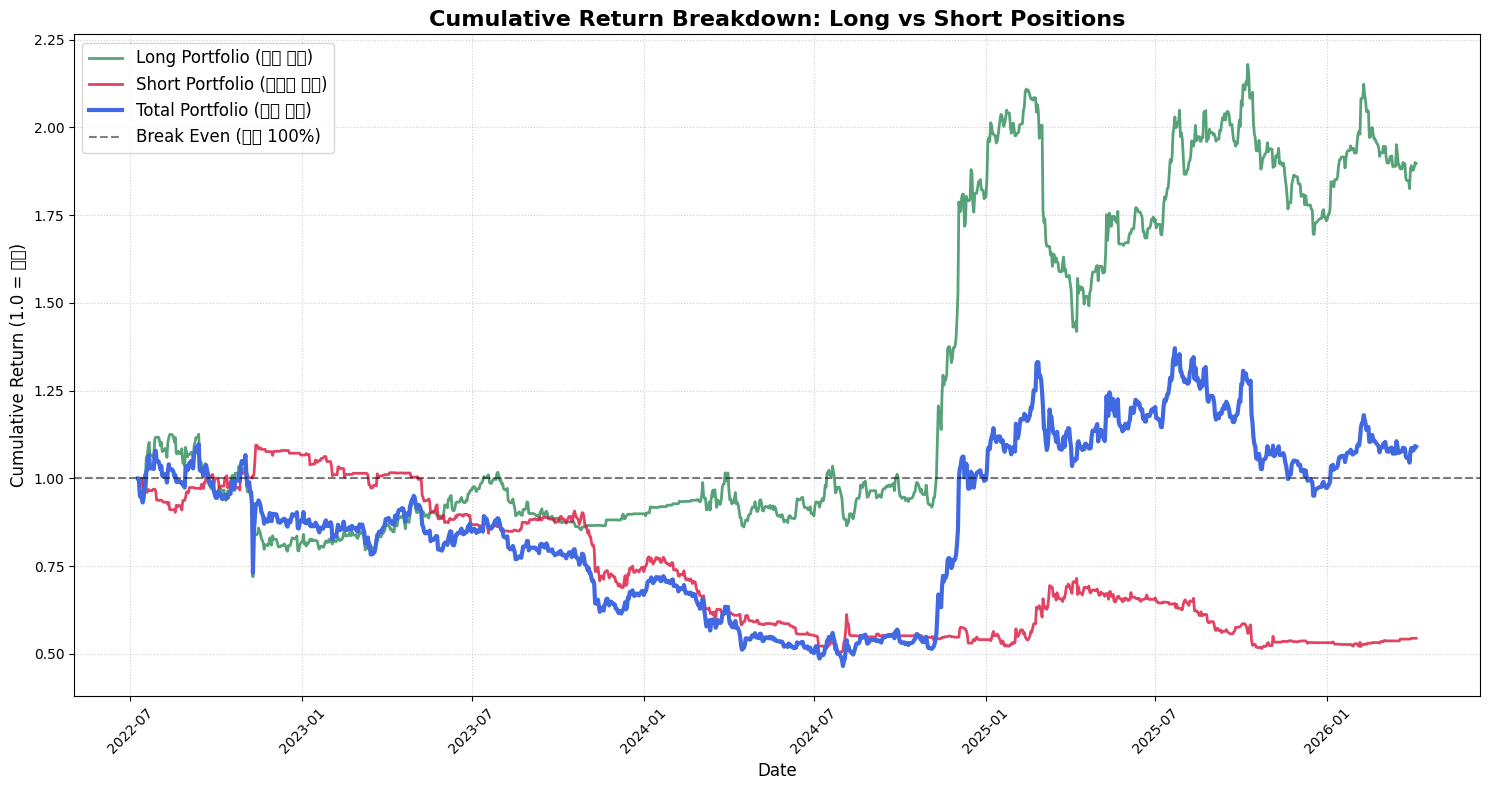

[포지션별 누적 수익률 기여도 최종 결과]
Long 포지션 단독 누적 성과 : 1.8970 (89.70%)
Short 포지션 단독 누적 성과: 0.5448 (-45.52%)
종합 포트폴리오 누적 성과  : 1.0907 (9.07%)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("롱(Long) / 숏(Short) 포지션별 수익률 기여도\n")

# 1. 롱/숏 포지션별로 데이터 분리
long_pf = total_portfolio_df[total_portfolio_df['position'] == 'Long']
short_pf = total_portfolio_df[total_portfolio_df['position'] == 'Short']

# 2. 날짜별 포지션 수익률 합산 (기존 strategy_return 활용)
daily_long = long_pf.groupby('target_date')['strategy_return'].sum().reset_index()
daily_long.rename(columns={'strategy_return': 'long_return'}, inplace=True)

daily_short = short_pf.groupby('target_date')['strategy_return'].sum().reset_index()
daily_short.rename(columns={'strategy_return': 'short_return'}, inplace=True)

daily_total = total_portfolio_df.groupby('target_date')['strategy_return'].sum().reset_index()
daily_total.rename(columns={'strategy_return': 'total_return'}, inplace=True)

# 3. 하나의 데이터프레임으로 병합 (결측치는 0으로 처리, 해당 날짜에 특정 포지션이 없을 수 있음)
perf_df = pd.merge(daily_total, daily_long, on='target_date', how='left').fillna(0)
perf_df = pd.merge(perf_df, daily_short, on='target_date', how='left').fillna(0)
perf_df = perf_df.sort_values('target_date')

# 4. 개별 누적 수익률(Cumulative Return) 계산
perf_df['cum_total'] = (1 + perf_df['total_return']).cumprod()
perf_df['cum_long'] = (1 + perf_df['long_return']).cumprod()
perf_df['cum_short'] = (1 + perf_df['short_return']).cumprod()

# 5. 시각화 (Long vs Short Breakdown)
plt.figure(figsize=(15, 8))

# 롱 포지션 누적 수익률 (초록색)
plt.plot(perf_df['target_date'], perf_df['cum_long'], label='Long Portfolio (매수 수익)', color='seagreen', linewidth=2, alpha=0.8)

# 숏 포지션 누적 수익률 (빨간색)
plt.plot(perf_df['target_date'], perf_df['cum_short'], label='Short Portfolio (공매도 수익)', color='crimson', linewidth=2, alpha=0.8)

# 전체 포트폴리오 누적 수익률 (파란색 굵은 선)
plt.plot(perf_df['target_date'], perf_df['cum_total'], label='Total Portfolio (종합 수익)', color='royalblue', linewidth=3)

# 원금 기준선
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Break Even (원금 100%)')

plt.title('Cumulative Return Breakdown: Long vs Short Positions', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 최종 수치 요약
print("="*60)
print("[포지션별 누적 수익률 기여도 최종 결과]")
print("="*60)
print(f"Long 포지션 단독 누적 성과 : {perf_df['cum_long'].iloc[-1]:.4f} ({(perf_df['cum_long'].iloc[-1]-1)*100:.2f}%)")
print(f"Short 포지션 단독 누적 성과: {perf_df['cum_short'].iloc[-1]:.4f} ({(perf_df['cum_short'].iloc[-1]-1)*100:.2f}%)")
print(f"종합 포트폴리오 누적 성과  : {perf_df['cum_total'].iloc[-1]:.4f} ({(perf_df['cum_total'].iloc[-1]-1)*100:.2f}%)")
print("="*60)

[임계값(Threshold) 적용] 엄격한 조건부 롱/숏 포트폴리오 백테스트 시작...



C:\Users\skack\AppData\Local\Temp\ipykernel_37568\984969853.py:85: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_37568\984969853.py:85: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


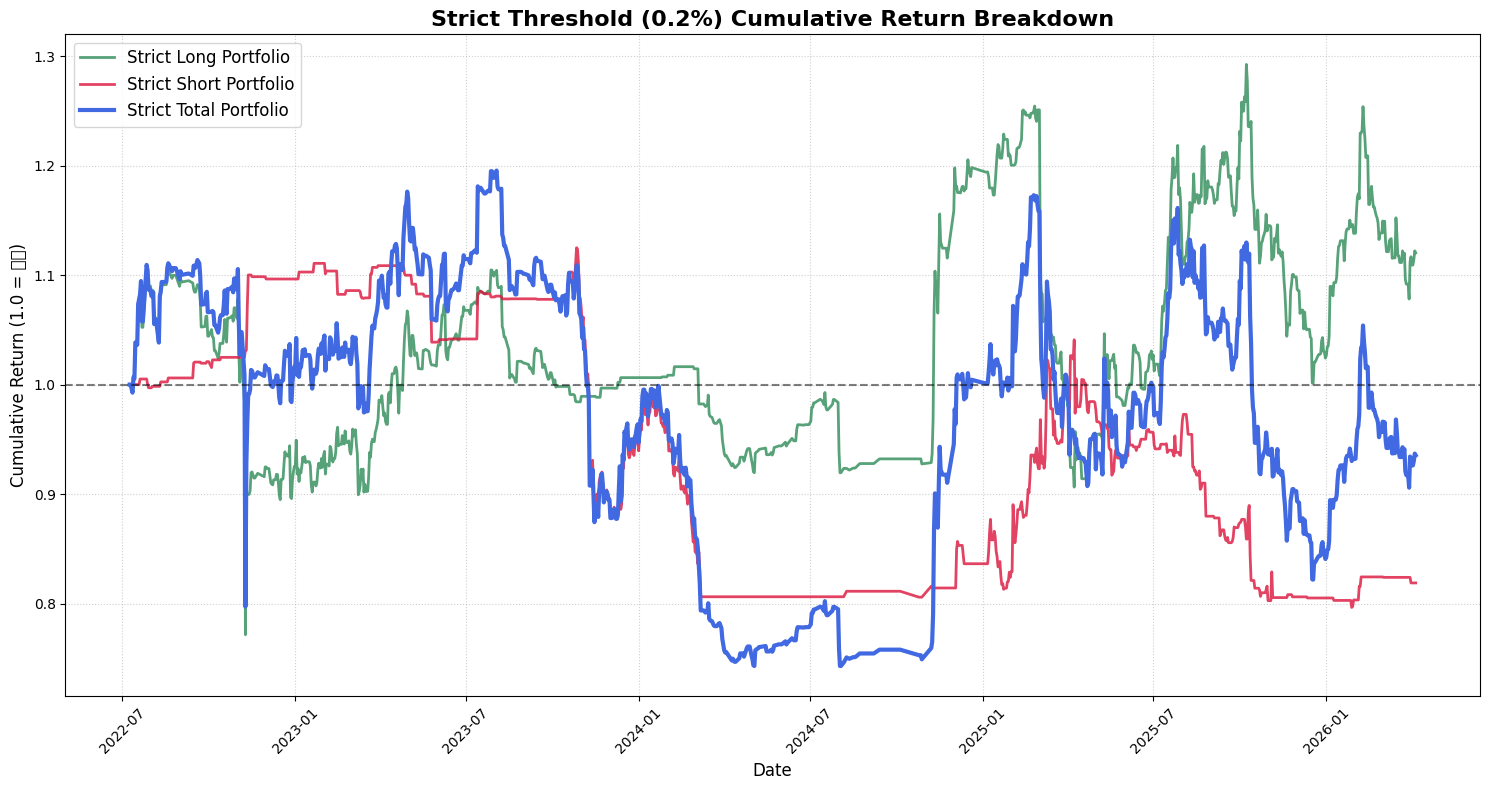

기존 포지션 진입 횟수: 54720 건 (대략치)
엄격한 필터링 후 진입 횟수: 5273 건
   - Long 진입: 3650 건
   - Short 진입: 1623 건
------------------------------------------------------------
Strict Long 성과 : 1.1202 (12.02%)
Strict Short 성과: 0.8189 (-18.11%)
Strict 종합 성과 : 0.9354 (-6.46%)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[임계값(Threshold) 적용] 엄격한 조건부 롱/숏 포트폴리오 백테스트 시작...\n")

# 앞서 학습이 끝난 전체 테스트 예측 결과(all_test_df)를 재활용 (재학습)
test_results_df = all_test_df.copy()

# 1. 강력한 진입 장벽(Threshold) 설정 (예: 0.2% 이상 변동이 예상될 때만 진입)
# (이 값을 0.003, 0.005 등으로 바꿔가며 테스트해볼 수 있습니다)
THRESHOLD = 0.002 

portfolio_list_strict = []

# 2. 새로운 엄격한 조건으로 포지션 재구성
for date, daily_data in test_results_df.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
    
    # [조건 1] 예측 수익률이 +THRESHOLD 보다 '클' 때만 매수
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predicted_return'] > THRESHOLD].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list_strict.append(long_stocks)
        
    # [조건 2] 예측 수익률이 -THRESHOLD 보다 '작을' 때만 공매도 (아주 확실한 하락 시그널)
    short_candidates = sorted_data.tail(5).copy()
    short_stocks = short_candidates[short_candidates['predicted_return'] < -THRESHOLD].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list_strict.append(short_stocks)

# 3. 새로운 포트폴리오 결합
if not portfolio_list_strict:
    print("설정한 임계값이 너무 높아 거래가 단 한 번도 발생하지 않았습니다.")
else:
    strict_portfolio_df = pd.concat(portfolio_list_strict).reset_index(drop=True)

    # 4. 수익률 재계산 (비중 20%)
    def calc_position_return_strict(row):
        if row['position'] == 'Long':
            return row['actual_target_return'] * (1/5)
        elif row['position'] == 'Short':
            return row['actual_target_return'] * (-1/5)
        return 0

    strict_portfolio_df['strategy_return'] = strict_portfolio_df.apply(calc_position_return_strict, axis=1)

    # 5. 롱/숏 분리 누적 수익률 계산
    long_strict = strict_portfolio_df[strict_portfolio_df['position'] == 'Long']
    short_strict = strict_portfolio_df[strict_portfolio_df['position'] == 'Short']

    daily_long = long_strict.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'long_return'})
    daily_short = short_strict.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'short_return'})
    daily_total = strict_portfolio_df.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'total_return'})

    perf_df = pd.merge(daily_total, daily_long, on='target_date', how='left').fillna(0)
    perf_df = pd.merge(perf_df, daily_short, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')

    perf_df['cum_total'] = (1 + perf_df['total_return']).cumprod()
    perf_df['cum_long'] = (1 + perf_df['long_return']).cumprod()
    perf_df['cum_short'] = (1 + perf_df['short_return']).cumprod()

    # 6. 결과 시각화
    plt.figure(figsize=(15, 8))
    plt.plot(perf_df['target_date'], perf_df['cum_long'], label='Strict Long Portfolio', color='seagreen', linewidth=2, alpha=0.8)
    plt.plot(perf_df['target_date'], perf_df['cum_short'], label='Strict Short Portfolio', color='crimson', linewidth=2, alpha=0.8)
    plt.plot(perf_df['target_date'], perf_df['cum_total'], label='Strict Total Portfolio', color='royalblue', linewidth=3)
    plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

    plt.title(f'Strict Threshold ({THRESHOLD*100}%) Cumulative Return Breakdown', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 결과 요약
    print("="*60)
    print(f"기존 포지션 진입 횟수: {len(test_results_df[test_results_df['predicted_return'] != 0])} 건 (대략치)")
    print(f"엄격한 필터링 후 진입 횟수: {len(strict_portfolio_df)} 건")
    print(f"   - Long 진입: {len(long_strict)} 건")
    print(f"   - Short 진입: {len(short_strict)} 건")
    print("-" * 60)
    print(f"Strict Long 성과 : {perf_df['cum_long'].iloc[-1]:.4f} ({(perf_df['cum_long'].iloc[-1]-1)*100:.2f}%)")
    print(f"Strict Short 성과: {perf_df['cum_short'].iloc[-1]:.4f} ({(perf_df['cum_short'].iloc[-1]-1)*100:.2f}%)")
    print(f"Strict 종합 성과 : {perf_df['cum_total'].iloc[-1]:.4f} ({(perf_df['cum_total'].iloc[-1]-1)*100:.2f}%)")
    print("="*60)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("[심층 진단] 예측 수익률 vs 실제 수익률 산점도 및 상관관계 분석 시작...\n")

# 앞서 저장된 전체 테스트 예측 결과(test_results_df) 활용
# 결측치나 무한대 값이 있을 수 있으므로 안전하게 제거
clean_df = test_results_df.dropna(subset=['predicted_return', 'actual_target_return'])

# 피어슨 상관계수 및 p-value 계산
corr, p_value = pearsonr(clean_df['predicted_return'], clean_df['actual_target_return'])

# 시각화 세팅
plt.figure(figsize=(12, 8))

# 산점도 및 회귀선(Trend line) 그리기
sns.regplot(
    x='predicted_return', 
    y='actual_target_return', 
    data=clean_df,
    scatter_kws={'alpha':0.2, 's':15, 'color':'royalblue'}, 
    line_kws={'color':'red', 'linewidth':2}
)

# 0 기준선 (십자가) 그리기
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)

# 그래프 꾸미기
plt.title(f'Model Prediction vs Actual Market Return\n(Pearson Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Return (Model)', fontsize=12)
plt.ylabel('Actual Return (Market)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 최종 수치 및 진단 가이드 출력
print("="*60)
print("[상관관계 분석 결과 요약]")
print(f"총 분석 데이터(점의 개수): {len(clean_df)} 개")
print(f"피어슨 상관계수(Correlation): {corr:.4f}")
print(f"p-value (통계적 유의성): {p_value:.4e}")

타겟 스케일링(x100)을 적용한 회귀 모델

학습 및 예측이 완료되었습니다. 검증을 위한 산점도를 생성합니다...



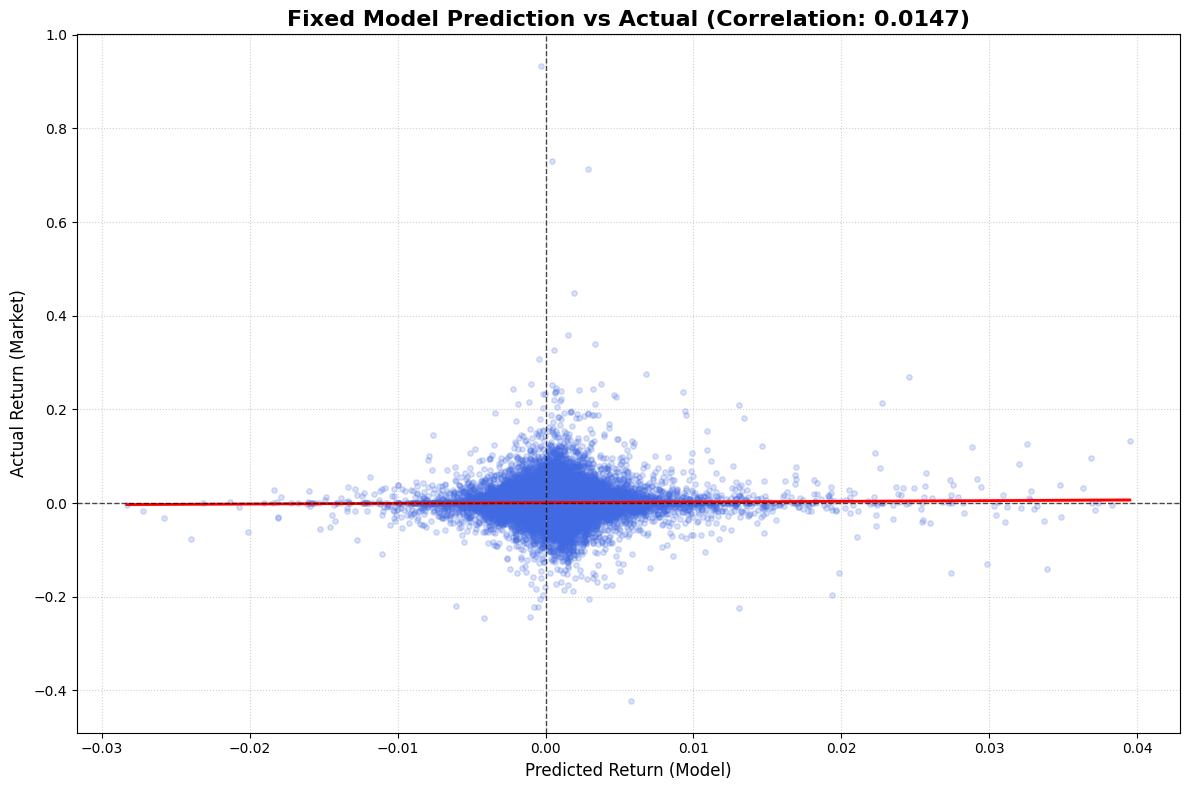

[수정 후 상관관계 분석 결과]
피어슨 상관계수(Correlation): 0.0147
p-value: 5.9395e-04
이전처럼 예측값이 0에 일직선으로 뭉치지 않고 넓게 퍼지며, 상관계수 수치가 개선되었는지 확인해 주십시오.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("타겟 스케일링(x100)을 적용한 회귀 모델\n")

seq_length = 30
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 30

all_portfolios = []
all_test_results = []

# 회귀 모델 아키텍처
class RegressionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(RegressionLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.1)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

for split_id in unique_splits:
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    
    # 🚨 [핵심 수정 사항] 훈련 시 정답 데이터에 * 100을 곱하여 Loss 규모를 정상화합니다.
    y_train = torch.tensor(train_df['actual_target_return'].values * 100, dtype=torch.float32).unsqueeze(-1)
    
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test = torch.tensor(test_df['actual_target_return'].values * 100, dtype=torch.float32).unsqueeze(-1)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
    
    model = RegressionLSTM(input_size=1, hidden_size=25)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 학습
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # 예측
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X).cpu().numpy().flatten()
            # 🚨 [핵심 수정 사항] 예측이 끝난 후 다시 100으로 나누어 원래 수익률 스케일로 복원합니다.
            all_preds.extend(preds / 100)

    test_df = test_df.copy()
    test_df['predicted_return'] = all_preds
    all_test_results.append(test_df)
    
    # 교수님 지시사항 적용 (포지션 진입 조건)
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10:
            continue
            
        sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
        
        long_stocks = sorted_data.head(5).copy()
        long_stocks = long_stocks[long_stocks['predicted_return'] > 0]
        if not long_stocks.empty:
            long_stocks['position'] = 'Long'
            portfolio_list.append(long_stocks)
            
        short_stocks = sorted_data.tail(5).copy()
        short_stocks = short_stocks[short_stocks['predicted_return'] < 0]
        if not short_stocks.empty:
            short_stocks['position'] = 'Short'
            portfolio_list.append(short_stocks)
            
    if portfolio_list:
        all_portfolios.append(pd.concat(portfolio_list))

print("학습 및 예측이 완료되었습니다. 검증을 위한 산점도를 생성합니다...\n")

# [산점도 및 상관관계 검증]
total_test_df = pd.concat(all_test_results).dropna(subset=['predicted_return', 'actual_target_return'])
corr, p_value = pearsonr(total_test_df['predicted_return'], total_test_df['actual_target_return'])

plt.figure(figsize=(12, 8))
sns.regplot(
    x='predicted_return', 
    y='actual_target_return', 
    data=total_test_df,
    scatter_kws={'alpha':0.2, 's':15, 'color':'royalblue'}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
plt.title(f'Fixed Model Prediction vs Actual (Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Return (Model)', fontsize=12)
plt.ylabel('Actual Return (Market)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("="*60)
print("[수정 후 상관관계 분석 결과]")
print(f"피어슨 상관계수(Correlation): {corr:.4f}")
print(f"p-value: {p_value:.4e}")
print("="*60)

# 처음부터 다시
# 90일 데이터 활용 회귀

In [1]:
import pandas as pd
import numpy as np

# 1. 90일치 시퀀스 데이터 불러오기
seq_file_path = './processed_sequences/train_data_seq_90d.csv'
try:
    df = pd.read_csv(seq_file_path)
except FileNotFoundError:
    print(f"오류: {seq_file_path} 파일을 찾을 수 없습니다. 파일명을 확인해주세요.")
    # 파일명이 다르다면 위 seq_file_path를 실제 90일 파일명으로 수정해주십시오.

df['target_date'] = pd.to_datetime(df['target_date'])

# 2. 실제 수익률 데이터 불러오기 (회귀 분석의 새로운 정답지)
returns_file_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)

# 3. 수익률 데이터를 병합을 위해 세로형(Long format)으로 변환
returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 4. 기존 데이터프레임에 실제 수익률 매핑 (Left Join)
merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')

# 결측치 처리 (수익률이 없는 날짜 제거)
initial_len = len(merged_df)
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)
dropped_len = initial_len - len(merged_df)

print("[데이터 병합 완료]")
print(f"- 사용된 시퀀스 길이: 90일 (예상)")
print(f"- 총 데이터 개수: {len(merged_df)}개 (결측치로 제거된 데이터: {dropped_len}개)")
print("\n[병합된 데이터 핵심 컬럼 상위 5개 미리보기]")
display(merged_df[['target_date', 'ticker', 'split_id', 'dataset_type', 'target', 'actual_target_return']].head())

[데이터 병합 완료]
- 사용된 시퀀스 길이: 90일 (예상)
- 총 데이터 개수: 186480개 (결측치로 제거된 데이터: 0개)

[병합된 데이터 핵심 컬럼 상위 5개 미리보기]


,target_date,ticker,split_id,dataset_type,target,actual_target_return
0,2021-07-08,NVDA,1,Train,0,-0.023022
1,2021-07-09,NVDA,1,Train,0,0.007411
2,2021-07-10,NVDA,1,Train,1,0.000000
3,2021-07-11,NVDA,1,Train,1,0.000000
4,2021-07-12,NVDA,1,Train,1,0.023055


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. 90일치 시퀀스 피처 컬럼 정의
seq_length = 90
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]

# 2. 첫 번째 Split 데이터만 분리 (아키텍처 및 텐서 차원 검증용)
target_split = 1
split_df = merged_df[merged_df['split_id'] == target_split]

train_df = split_df[split_df['dataset_type'] == 'Train']
test_df = split_df[split_df['dataset_type'] == 'Test']

# 3. PyTorch 텐서 변환 (핵심: 타겟 데이터 스케일링 x100 적용)
# 수익률이 너무 작아 발생하는 MSE Loss의 소실을 방지하기 위해 정답에 100을 곱합니다.
X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(train_df['actual_target_return'].values * 100, dtype=torch.float32).unsqueeze(-1)

X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(test_df['actual_target_return'].values * 100, dtype=torch.float32).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

# 4. 회귀(Regression)용 LSTM 아키텍처 전면 개편
class RegressionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(RegressionLSTM, self).__init__()
        # 내부 구조를 최적화된 nn.LSTM으로 교체하여 학습 속도 극대화
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.1)
        # 최종 출력은 '예측 수익률' 단일 실수값이므로 출력 차원은 1
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # 마지막 90일차(t 시점)의 은닉 상태만 추출
        last_time_step_out = lstm_out[:, -1, :] 
        out = self.dropout(last_time_step_out)
        out = self.fc(out) 
        return out

# 모델 객체 생성 및 텐서 차원 테스트
model = RegressionLSTM(input_size=1, hidden_size=25)
model.eval()

dummy_input = torch.randn(5, 90, 1) # 5개 샘플, 90일 시퀀스, 1개 피처
with torch.no_grad():
    sample_output = model(dummy_input)

print("[90일 기반 회귀 모델 아키텍처 구축 완료]")
print(f"- Train X 텐서 형태: {X_train_tensor.shape}")
print(f"- Train y 텐서 형태: {y_train_tensor.shape} (스케일링 적용됨)")
print("\n[더미 데이터 테스트 출력 (5개 샘플)]")
print(sample_output)
print("-> 입력 시퀀스 90일을 거쳐 최종적으로 단일 수익률(스케일링된 값) 1개를 출력하도록 정상 작동합니다.")

[90일 기반 회귀 모델 아키텍처 구축 완료]
- Train X 텐서 형태: torch.Size([14640, 90, 1])
- Train y 텐서 형태: torch.Size([14640, 1]) (스케일링 적용됨)

[더미 데이터 테스트 출력 (5개 샘플)]
tensor([[0.0198],
        [0.0218],
        [0.0265],
        [0.0201],
        [0.0293]])
-> 입력 시퀀스 90일을 거쳐 최종적으로 단일 수익률(스케일링된 값) 1개를 출력하도록 정상 작동합니다.


In [3]:
import torch.optim as optim

# 1. 학습 세팅 (MSELoss 사용)
num_epochs = 40 
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("[Split 1] 회귀 모델 학습 시작...")

# 2. 모델 학습
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train MSE Loss: {running_loss / len(train_loader):.6f}")

print("학습 완료.")

# 3. 테스트 데이터 예측
model.eval()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X).cpu().numpy().flatten()
        all_preds.extend(preds / 100) # 스케일링 복구

test_df = test_df.copy()
test_df['predicted_return'] = all_preds

# 4. 조건부 롱/숏 포트폴리오 구성
portfolio_list = []
for date, daily_data in test_df.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
    
    # 상위 5개 중 예측 수익률 > 0 인 경우만 Long
    top_5 = sorted_data.head(5).copy()
    long_stocks = top_5[top_5['predicted_return'] > 0].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list.append(long_stocks)
        
    # 하위 5개 중 예측 수익률 < 0 인 경우만 Short
    bottom_5 = sorted_data.tail(5).copy()
    short_stocks = bottom_5[bottom_5['predicted_return'] < 0].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list.append(short_stocks)

if portfolio_list:
    final_portfolio = pd.concat(portfolio_list).reset_index(drop=True)
    print(f"포트폴리오 생성 완료. 총 거래 건수: {len(final_portfolio)}")
    display(final_portfolio[['target_date', 'ticker', 'predicted_return', 'actual_target_return', 'position']].head(10))
else:
    print("조건을 만족하는 포지션이 없습니다.")

[Split 1] 회귀 모델 학습 시작...
Epoch [10/40] Train MSE Loss: 7.501955
Epoch [20/40] Train MSE Loss: 7.396553
Epoch [30/40] Train MSE Loss: 7.446479
Epoch [40/40] Train MSE Loss: 7.376429
학습 완료.
포트폴리오 생성 완료. 총 거래 건수: 1504


,target_date,ticker,predicted_return,actual_target_return,position
0,2022-07-09,XRP-USD,0.004890,0.00973,Long
1,2022-07-09,AMD,0.004562,0.00000,Long
2,2022-07-09,NVDA,0.004512,0.00000,Long
3,2022-07-09,TRX-USD,0.004161,0.01175,Long
4,2022-07-09,AVGO,0.004002,0.00000,Long
5,2022-07-09,JPM,-0.002150,0.00000,Short
6,2022-07-09,V,-0.003077,0.00000,Short
7,2022-07-09,CAT,-0.004508,0.00000,Short
8,2022-07-09,CVX,-0.005384,0.00000,Short
9,2022-07-09,XOM,-0.005889,0.00000,Short


전체 데이터 구간에 대한 90일 모델 학습 및 백테스트를 시작합니다.
--- [Split 1] 학습 및 예측 진행 ---
--- [Split 2] 학습 및 예측 진행 ---
--- [Split 3] 학습 및 예측 진행 ---
--- [Split 4] 학습 및 예측 진행 ---
--- [Split 5] 학습 및 예측 진행 ---
--- [Split 6] 학습 및 예측 진행 ---
--- [Split 7] 학습 및 예측 진행 ---
--- [Split 8] 학습 및 예측 진행 ---
--- [Split 9] 학습 및 예측 진행 ---


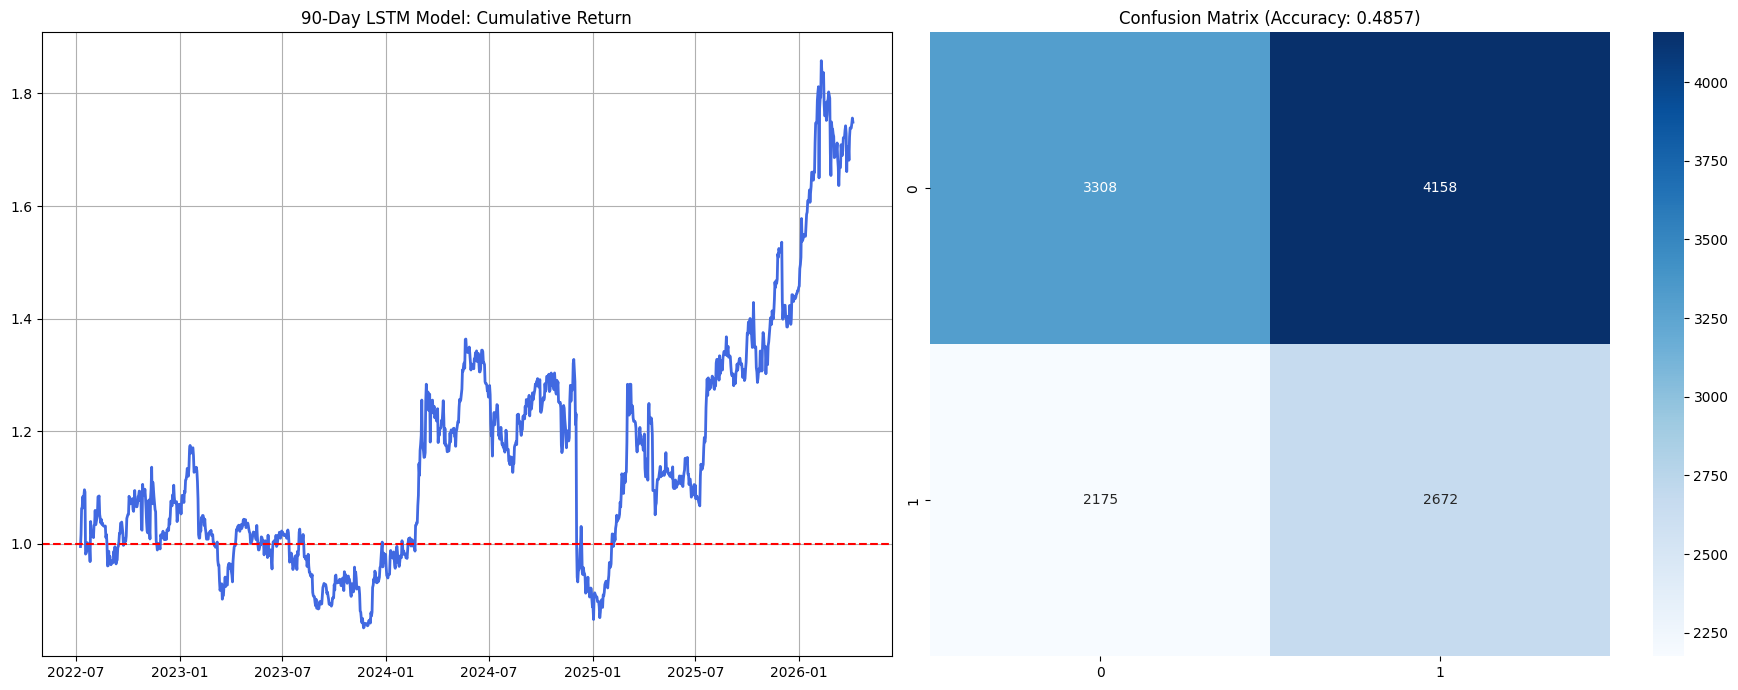

              precision    recall  f1-score   support

 Short(Down)       0.60      0.44      0.51      7466
    Long(Up)       0.39      0.55      0.46      4847

    accuracy                           0.49     12313
   macro avg       0.50      0.50      0.48     12313
weighted avg       0.52      0.49      0.49     12313



In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 모델 클래스 정의
class RegressionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(RegressionLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.1)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

print("전체 데이터 구간에 대한 90일 모델 학습 및 백테스트를 시작합니다.")

all_portfolios = []
all_test_results = []
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 40

for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 예측 진행 ---")
    
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['actual_target_return'].values * 100, dtype=torch.float32).unsqueeze(-1)
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, torch.tensor(test_df['actual_target_return'].values, dtype=torch.float32).unsqueeze(-1)), batch_size=256, shuffle=False)
    
    model = RegressionLSTM(input_size=1, hidden_size=25)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            preds = model(batch_X).cpu().numpy().flatten()
            all_preds.extend(preds / 100)

    test_df = test_df.copy()
    test_df['predicted_return'] = all_preds
    all_test_results.append(test_df)
    
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10:
            continue
        sorted_data = daily_data.sort_values(by='predicted_return', ascending=False)
        
        long_stocks = sorted_data.head(5).copy()
        long_stocks = long_stocks[long_stocks['predicted_return'] > 0]
        if not long_stocks.empty:
            long_stocks['position'] = 'Long'
            portfolio_list.append(long_stocks)
            
        short_stocks = sorted_data.tail(5).copy()
        short_stocks = short_stocks[short_stocks['predicted_return'] < 0]
        if not short_stocks.empty:
            short_stocks['position'] = 'Short'
            portfolio_list.append(short_stocks)
            
    if portfolio_list:
        all_portfolios.append(pd.concat(portfolio_list))

# 결과 산출
total_portfolio_df = pd.concat(all_portfolios).reset_index(drop=True)

# 포지션별 수익률 계산
def calc_position_return(row):
    if row['position'] == 'Long':
        return row['actual_target_return'] * (1/5)
    elif row['position'] == 'Short':
        return row['actual_target_return'] * (-1/5)
    return 0

total_portfolio_df['strategy_return'] = total_portfolio_df.apply(calc_position_return, axis=1)

# 누적 수익률 그래프
daily_returns = total_portfolio_df.groupby('target_date')['strategy_return'].sum().reset_index()
daily_returns = daily_returns.sort_values('target_date')
daily_returns['cumulative_return'] = (1 + daily_returns['strategy_return']).cumprod()

# 혼동 행렬 데이터
total_portfolio_df['pred_class'] = total_portfolio_df['position'].apply(lambda x: 1 if x == 'Long' else 0)
total_portfolio_df['actual_class'] = total_portfolio_df['actual_target_return'].apply(lambda x: 1 if x > 0 else 0)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].plot(daily_returns['target_date'], daily_returns['cumulative_return'], color='royalblue', linewidth=2)
axes[0].axhline(y=1.0, color='red', linestyle='--')
axes[0].set_title('90-Day LSTM Model: Cumulative Return')
axes[0].grid(True)

cm = confusion_matrix(total_portfolio_df['actual_class'], total_portfolio_df['pred_class'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Accuracy: {accuracy_score(total_portfolio_df["actual_class"], total_portfolio_df["pred_class"]):.4f})')
plt.tight_layout()
plt.show()

print("="*60)
print(classification_report(total_portfolio_df['actual_class'], total_portfolio_df['pred_class'], target_names=['Short(Down)', 'Long(Up)']))
print("="*60)

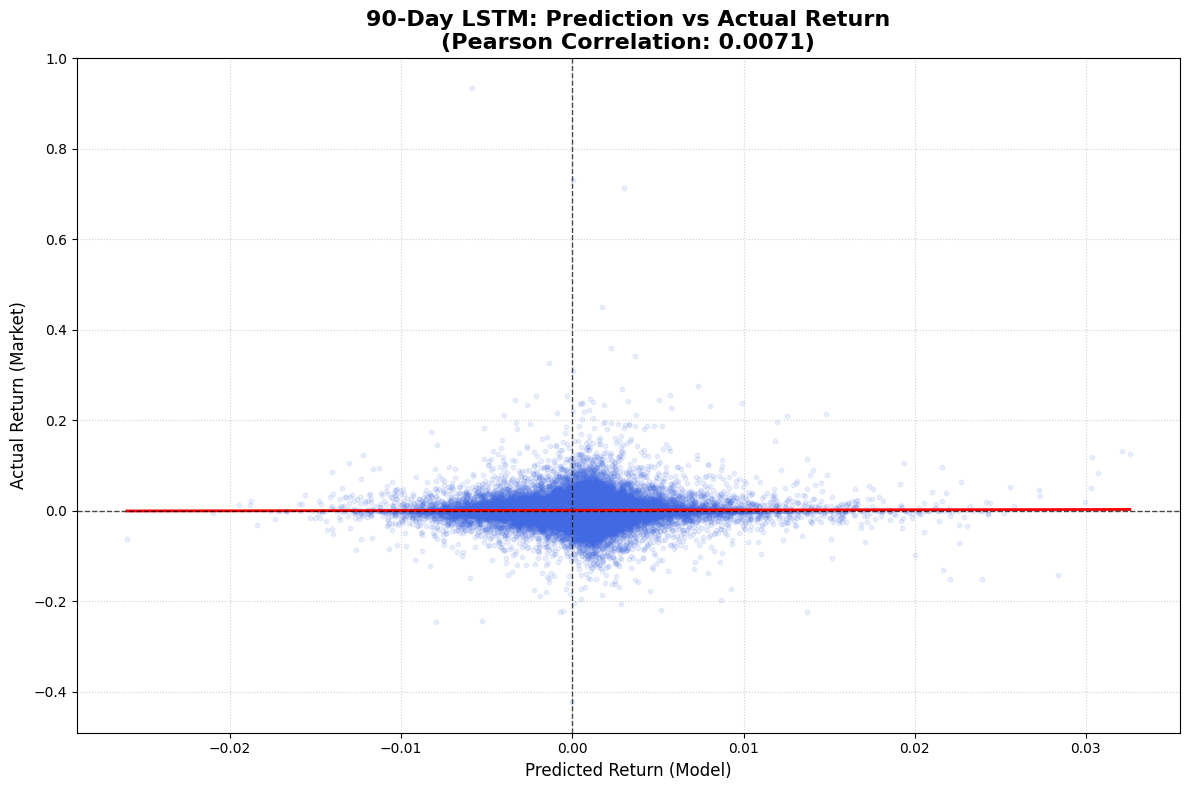

[90일 시퀀스 모델 상관관계 분석 결과]
분석 데이터 개수: 54720 개
피어슨 상관계수 (Correlation): 0.0071
p-value: 9.5803e-02
------------------------------------------------------------
해석 가이드:
1. 상관계수가 0.05 이상인 경우: 유의미한 예측력을 확보하기 위한 첫걸음을 뗐습니다.
2. 상관계수가 여전히 0에 가깝다면: 모델이 시퀀스 데이터를 통해 시장 방향성을 전혀 읽지 못하는 상태입니다.
3. 이 산점도의 분포가 여전히 0 근처에만 집중되어 있다면: 데이터 정규화 범위를 점검하거나 타겟 스케일링 값을 조정해야 합니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pandas as pd

# 1. 전체 테스트 구간 결과 통합 및 결측치 제거
total_test_df = pd.concat(all_test_results).dropna(subset=['predicted_return', 'actual_target_return'])

# 2. 피어슨 상관계수 및 p-value 계산
corr, p_value = pearsonr(total_test_df['predicted_return'], total_test_df['actual_target_return'])

# 3. 산점도 및 추세선 시각화
plt.figure(figsize=(12, 8))
sns.regplot(
    x='predicted_return', 
    y='actual_target_return', 
    data=total_test_df,
    scatter_kws={'alpha':0.1, 's':10, 'color':'royalblue'}, 
    line_kws={'color':'red', 'linewidth':2}
)

plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)

plt.title(f'90-Day LSTM: Prediction vs Actual Return\n(Pearson Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Return (Model)', fontsize=12)
plt.ylabel('Actual Return (Market)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 결과 요약 출력
print("============================================================")
print("[90일 시퀀스 모델 상관관계 분석 결과]")
print("============================================================")
print(f"분석 데이터 개수: {len(total_test_df)} 개")
print(f"피어슨 상관계수 (Correlation): {corr:.4f}")
print(f"p-value: {p_value:.4e}")

# 다시

In [1]:
import pandas as pd
import numpy as np

print("90일 시퀀스 데이터 및 실제 수익률 로드 시작...")

# 1. 90일 데이터 불러오기 
# (이 데이터의 'target' 컬럼에는 이미 과거 전처리 과정에서 만들어둔 0과 1 분류 정답지가 들어있습니다)
seq_file_path = './processed_sequences/train_data_seq_90d.csv'
df = pd.read_csv(seq_file_path)
df['target_date'] = pd.to_datetime(df['target_date'])

# 2. 실제 수익률 데이터 불러오기
# (학습에는 쓰지 않지만, 셀 3의 누적 수익률 계산과 셀 4의 상관계수 분석을 위해 필요합니다)
returns_file_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 3. 데이터 병합 (분류용 정답지와 실제 수익률을 한 곳에 모음)
merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
initial_len = len(merged_df)
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)

print("데이터 로드 및 병합 완료!")
print(f"총 데이터 개수: {len(merged_df)} 개")
print("\n[병합된 데이터 핵심 컬럼 미리보기]")
display(merged_df[['target_date', 'ticker', 'split_id', 'dataset_type', 'target', 'actual_target_return']].head())

90일 시퀀스 데이터 및 실제 수익률 로드 시작...
데이터 로드 및 병합 완료!
총 데이터 개수: 186480 개

[병합된 데이터 핵심 컬럼 미리보기]


,target_date,ticker,split_id,dataset_type,target,actual_target_return
0,2021-07-08,NVDA,1,Train,0,-0.023022
1,2021-07-09,NVDA,1,Train,0,0.007411
2,2021-07-10,NVDA,1,Train,1,0.000000
3,2021-07-11,NVDA,1,Train,1,0.000000
4,2021-07-12,NVDA,1,Train,1,0.023055


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

print("90일 기반 분류(Classification) 모델 학습 및 확률 예측 시작...")

seq_length = 90
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 40 

all_test_results = []

# 분류용 LSTM 모델 아키텍처 (출력 차원: 2)
class ClassificationLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(ClassificationLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.1)
        # 클래스 0(하회)과 1(상회)에 대한 Logit 값 출력
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

# 전체 Split 순회 학습 및 예측
for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 예측 진행 중 ---")
    
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
        
    # X: 90일 시퀀스, y: 이진 정답지(0 또는 1)
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['target'].values, dtype=torch.long)
    
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test = torch.tensor(test_df['target'].values, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
    
    model = ClassificationLSTM(input_size=1, hidden_size=25)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 모델 학습
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # 테스트 세트에 대한 상승 확률(Probability) 예측
    model.eval()
    split_probs = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            outputs = model(batch_X)
            # Softmax를 통과시켜 0~1 사이의 확률값으로 변환
            probs = F.softmax(outputs, dim=1)
            # 인덱스 1번(클래스 1, 즉 상회할 확률)만 추출
            prob_of_1 = probs[:, 1].cpu().numpy()
            split_probs.extend(prob_of_1)
            
    test_df = test_df.copy()
    test_df['predict_prob'] = split_probs
    all_test_results.append(test_df)

# 전체 테스트 예측 결과 병합
total_test_results = pd.concat(all_test_results).reset_index(drop=True)

print("\n학습 및 확률 예측 완료!")
print("[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]")
sample_date = total_test_results['target_date'].unique()[0]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

90일 기반 분류(Classification) 모델 학습 및 확률 예측 시작...
--- [Split 1] 학습 및 예측 진행 중 ---
--- [Split 2] 학습 및 예측 진행 중 ---
--- [Split 3] 학습 및 예측 진행 중 ---
--- [Split 4] 학습 및 예측 진행 중 ---
--- [Split 5] 학습 및 예측 진행 중 ---
--- [Split 6] 학습 및 예측 진행 중 ---
--- [Split 7] 학습 및 예측 진행 중 ---
--- [Split 8] 학습 및 예측 진행 중 ---
--- [Split 9] 학습 및 예측 진행 중 ---

학습 및 확률 예측 완료!
[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-09,UNH,1,0.000000,0.941314
1,2022-07-09,META,1,0.000000,0.934327
2,2022-07-09,WMT,1,0.000000,0.930924
3,2022-07-09,ORCL,1,0.000000,0.930064
4,2022-07-09,CVX,1,0.000000,0.929708
5,2022-07-09,AMZN,1,0.000000,0.929358
6,2022-07-09,JNJ,1,0.000000,0.927822
7,2022-07-09,PLTR,1,0.000000,0.926418
8,2022-07-09,GOOGL,1,0.000000,0.924786
9,2022-07-09,MSFT,1,0.000000,0.919361


In [3]:
print("[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]")
sample_date = total_test_results['target_date'].unique()[3]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-12,XRP-USD,1,-0.008393,0.530011
1,2022-07-12,ORCL,0,-0.016208,0.518846
2,2022-07-12,UNH,1,-0.004894,0.518833
3,2022-07-12,JNJ,0,-0.014018,0.517262
4,2022-07-12,WMT,1,-0.003029,0.516092
5,2022-07-12,USDT-USD,1,0.000118,0.515738
6,2022-07-12,LLY,0,-0.022594,0.514802
7,2022-07-12,HD,1,-0.004435,0.514608
8,2022-07-12,XOM,0,-0.013311,0.513564
9,2022-07-12,ABBV,0,-0.005025,0.513559


In [4]:
print("[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]")
sample_date = total_test_results['target_date'].unique()[5]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-14,SOL-USD,1,0.062928,0.540049
1,2022-07-14,DOGE-USD,0,0.007118,0.538947
2,2022-07-14,TRX-USD,0,0.009646,0.538738
3,2022-07-14,ETH-USD,1,0.069989,0.528820
4,2022-07-14,BNB-USD,1,0.033141,0.524171
5,2022-07-14,BTC-USD,1,0.017705,0.523435
6,2022-07-14,USDC-USD,0,-0.000050,0.516068
7,2022-07-14,ADA-USD,0,0.006658,0.510859
8,2022-07-14,XRP-USD,1,0.029318,0.499641
9,2022-07-14,TSLA,1,0.005372,0.494388


In [5]:
print("[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]")
sample_date = total_test_results['target_date'].unique()[10]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-19,TSLA,0,0.020717,0.522845
1,2022-07-19,AMZN,1,0.039117,0.522108
2,2022-07-19,PLTR,1,0.034330,0.521349
3,2022-07-19,AVGO,1,0.036533,0.520222
4,2022-07-19,CAT,1,0.041790,0.519158
5,2022-07-19,NVDA,1,0.055338,0.519000
6,2022-07-19,AMD,1,0.054648,0.518751
7,2022-07-19,USDT-USD,0,0.000315,0.517661
8,2022-07-19,META,1,0.051127,0.516598
9,2022-07-19,USDC-USD,0,-0.000185,0.516567


[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...



c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


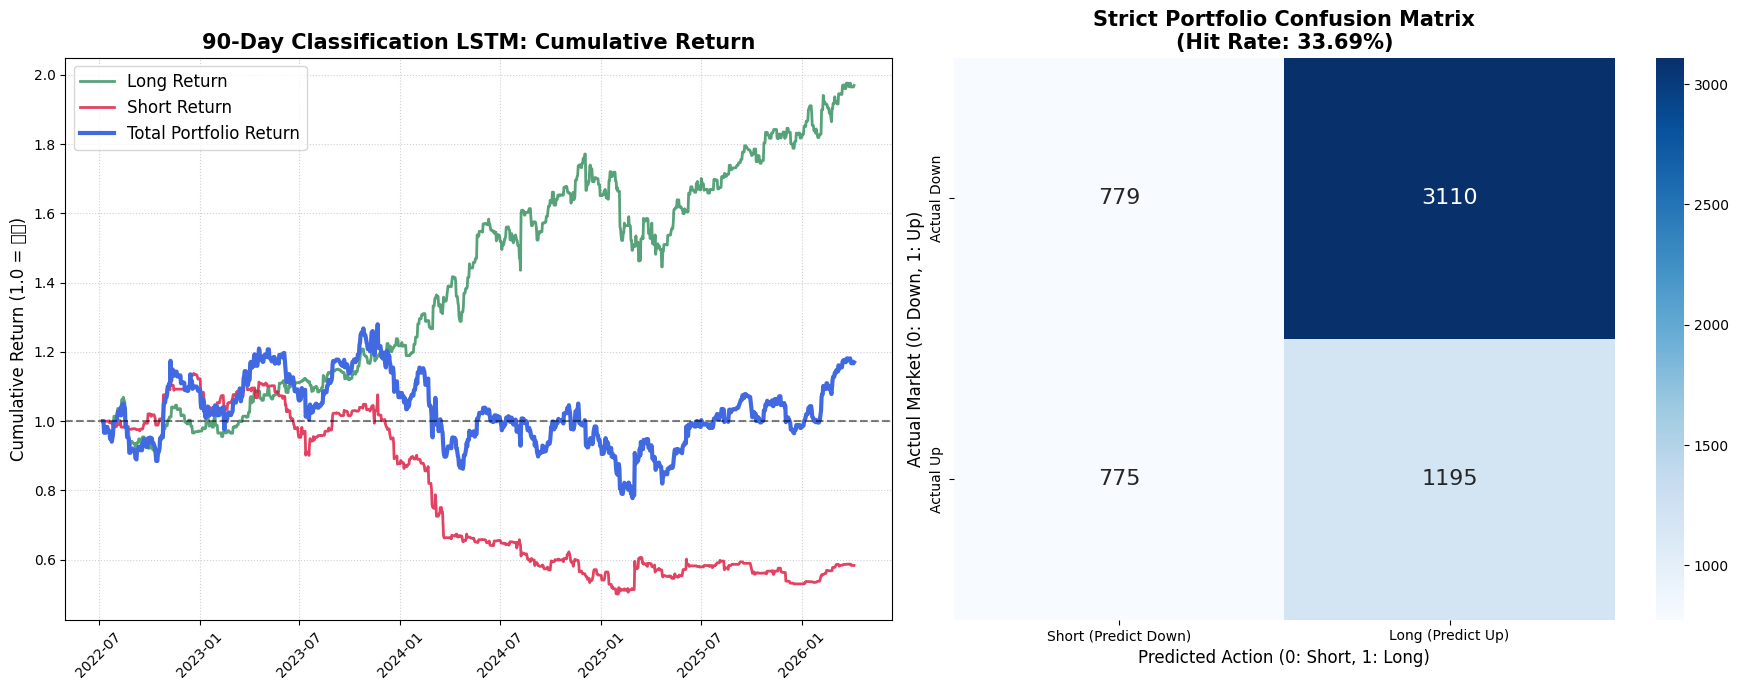

[엄격한 조건부 포트폴리오 백테스트 요약]
총 거래(포지션 진입) 횟수: 5859 건
 - Long(매수) 진입 횟수 : 4305 건
 - Short(공매도) 진입 횟수: 1554 건
------------------------------------------------------------
Long 포지션 누적 성과 : 1.9698 (96.98%)
Short 포지션 누적 성과: 0.5831 (-41.69%)
종합 포트폴리오 누적 성과: 1.1699 (16.99%)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import confusion_matrix, accuracy_score

print("[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...\n")

# 1. 🚨 모델의 '확신' 임계값(Threshold) 설정
# (주식 시장의 노이즈를 고려하여, 모델이 꽤 강하게 확신할 때만 진입합니다. 필요시 수치를 조정할 수 있습니다.)
LONG_THRESHOLD = 0.55  # 상회할 확률이 55% 이상일 때만 매수
SHORT_THRESHOLD = 0.45 # 상회할 확률이 45% 이하 (즉, 하회할 확률이 55% 이상)일 때만 공매도

portfolio_list = []

# 2. 날짜별 포지션 선정
for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 확률을 기준으로 내림차순 정렬 (1등 ~ 꼴등)
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # [조건 1] 상위 5개 중, 상승 확신이 충분히 큰(LONG_THRESHOLD 이상) 종목만 Long
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] >= LONG_THRESHOLD].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list.append(long_stocks)
        
    # [조건 2] 하위 5개 중, 하락 확신이 엄청나게 큰(SHORT_THRESHOLD 이하) 종목만 Short
    short_candidates = sorted_data.tail(5).copy()
    short_stocks = short_candidates[short_candidates['predict_prob'] <= SHORT_THRESHOLD].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list.append(short_stocks)

if not portfolio_list:
    print("설정한 임계값 조건을 만족하는 거래가 단 한 번도 발생하지 않았습니다. Threshold를 완화해주세요.")
else:
    final_portfolio = pd.concat(portfolio_list).reset_index(drop=True)
    
    # 3. 수익률 계산 (포트폴리오 비중 20% 고정)
    def calc_position_return(row):
        if row['position'] == 'Long':
            return row['actual_target_return'] * (1/5)
        elif row['position'] == 'Short':
            return row['actual_target_return'] * (-1/5)
        return 0

    final_portfolio['strategy_return'] = final_portfolio.apply(calc_position_return, axis=1)

    # 롱/숏 성과 분리
    long_pf = final_portfolio[final_portfolio['position'] == 'Long']
    short_pf = final_portfolio[final_portfolio['position'] == 'Short']

    daily_long = long_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'long_return'})
    daily_short = short_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'short_return'})
    daily_total = final_portfolio.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'total_return'})

    perf_df = pd.merge(daily_total, daily_long, on='target_date', how='left').fillna(0)
    perf_df = pd.merge(perf_df, daily_short, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')

    perf_df['cum_total'] = (1 + perf_df['total_return']).cumprod()
    perf_df['cum_long'] = (1 + perf_df['long_return']).cumprod()
    perf_df['cum_short'] = (1 + perf_df['short_return']).cumprod()

    # 4. 혼동 행렬(Confusion Matrix) 평가 준비
    # Pred: Long은 1(상승 예측), Short은 0(하락 예측)
    # Actual: 실제 수익률 > 0 이면 1(실제 상승), <= 0 이면 0(실제 하락)
    final_portfolio['pred_class'] = final_portfolio['position'].apply(lambda x: 1 if x == 'Long' else 0)
    final_portfolio['actual_class'] = final_portfolio['actual_target_return'].apply(lambda x: 1 if x > 0 else 0)

    cm = confusion_matrix(final_portfolio['actual_class'], final_portfolio['pred_class'])
    acc = accuracy_score(final_portfolio['actual_class'], final_portfolio['pred_class'])

    # 5. 결과 시각화
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 그래프 1: 롱/숏 분리 누적 수익률
    axes[0].plot(perf_df['target_date'], perf_df['cum_long'], label='Long Return', color='seagreen', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_short'], label='Short Return', color='crimson', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_total'], label='Total Portfolio Return', color='royalblue', linewidth=3)
    axes[0].axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

    axes[0].set_title('90-Day Classification LSTM: Cumulative Return', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    axes[0].legend(fontsize=12, loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].tick_params(axis='x', rotation=45)

    # 그래프 2: 혼동 행렬
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16})
    axes[1].set_title(f'Strict Portfolio Confusion Matrix\n(Hit Rate: {acc*100:.2f}%)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Predicted Action (0: Short, 1: Long)', fontsize=12)
    axes[1].set_ylabel('Actual Market (0: Down, 1: Up)', fontsize=12)
    axes[1].set_xticklabels(['Short (Predict Down)', 'Long (Predict Up)'])
    axes[1].set_yticklabels(['Actual Down', 'Actual Up'])

    plt.tight_layout()
    plt.show()

    # 최종 결과 요약 출력
    print("="*60)
    print("[엄격한 조건부 포트폴리오 백테스트 요약]")
    print(f"총 거래(포지션 진입) 횟수: {len(final_portfolio)} 건")
    print(f" - Long(매수) 진입 횟수 : {len(long_pf)} 건")
    print(f" - Short(공매도) 진입 횟수: {len(short_pf)} 건")
    print("-" * 60)
    print(f"Long 포지션 누적 성과 : {perf_df['cum_long'].iloc[-1]:.4f} ({(perf_df['cum_long'].iloc[-1]-1)*100:.2f}%)")
    print(f"Short 포지션 누적 성과: {perf_df['cum_short'].iloc[-1]:.4f} ({(perf_df['cum_short'].iloc[-1]-1)*100:.2f}%)")
    print(f"종합 포트폴리오 누적 성과: {perf_df['cum_total'].iloc[-1]:.4f} ({(perf_df['cum_total'].iloc[-1]-1)*100:.2f}%)")
    print("="*60)

[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...



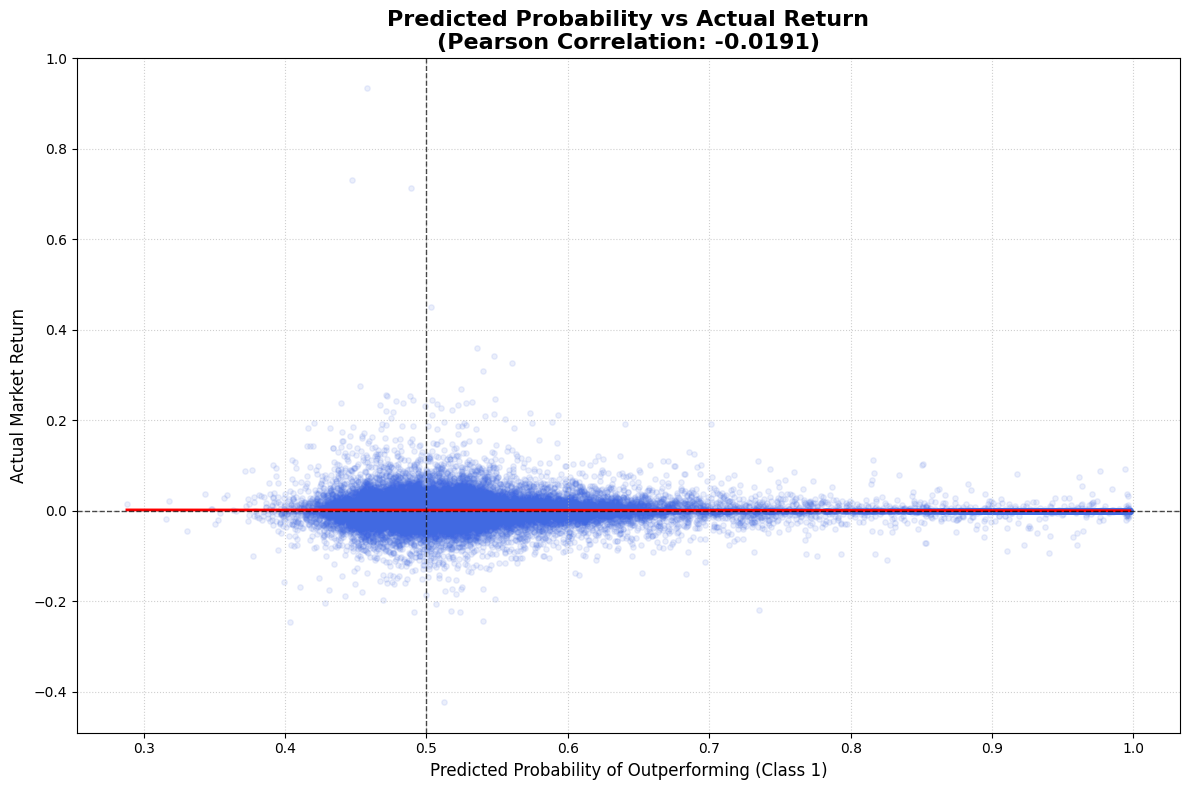

[예측 확률 기반 상관관계 분석 결과]
분석 데이터 개수: 54720 개
피어슨 상관계수(Correlation): -0.0191
p-value: 7.7762e-06
------------------------------------------------------------
[그래프 해석 가이드]
1. 추세선의 방향 (빨간 선):
   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.
   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)
2. 사분면 분포 (십자가 기준):
   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)
   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)
   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...\n")

# 1. 평가를 위한 데이터 정리 (결측치 제거)
# 전체 테스트 결과(total_test_results)를 사용하여 모델의 전반적인 예측력을 평가합니다.
eval_df = total_test_results.dropna(subset=['predict_prob', 'actual_target_return'])

# 2. 피어슨 상관계수 및 p-value 계산
corr, p_value = pearsonr(eval_df['predict_prob'], eval_df['actual_target_return'])

# 3. 산점도 및 추세선 시각화
plt.figure(figsize=(12, 8))

sns.regplot(
    x='predict_prob', 
    y='actual_target_return', 
    data=eval_df,
    scatter_kws={'alpha': 0.1, 's': 15, 'color': 'royalblue'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

# 기준선 그리기
# 가로선: 수익률 0 (수익/손실 경계)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
# 세로선: 확률 0.5 (상승/하락 예측 경계)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)

plt.title(f'Predicted Probability vs Actual Return\n(Pearson Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Probability of Outperforming (Class 1)', fontsize=12)
plt.ylabel('Actual Market Return', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 결과 요약 출력
print("============================================================")
print("[예측 확률 기반 상관관계 분석 결과]")
print(f"분석 데이터 개수: {len(eval_df)} 개")
print(f"피어슨 상관계수(Correlation): {corr:.4f}")
print(f"p-value: {p_value:.4e}")
print("------------------------------------------------------------")
print("[그래프 해석 가이드]")
print("1. 추세선의 방향 (빨간 선):")
print("   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.")
print("   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)")
print("2. 사분면 분포 (십자가 기준):")
print("   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)")
print("   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)")
print("   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.")
print("============================================================")

[추가 분석] 롱/숏 예측 방향별 피어슨 상관계수 분석 시작...



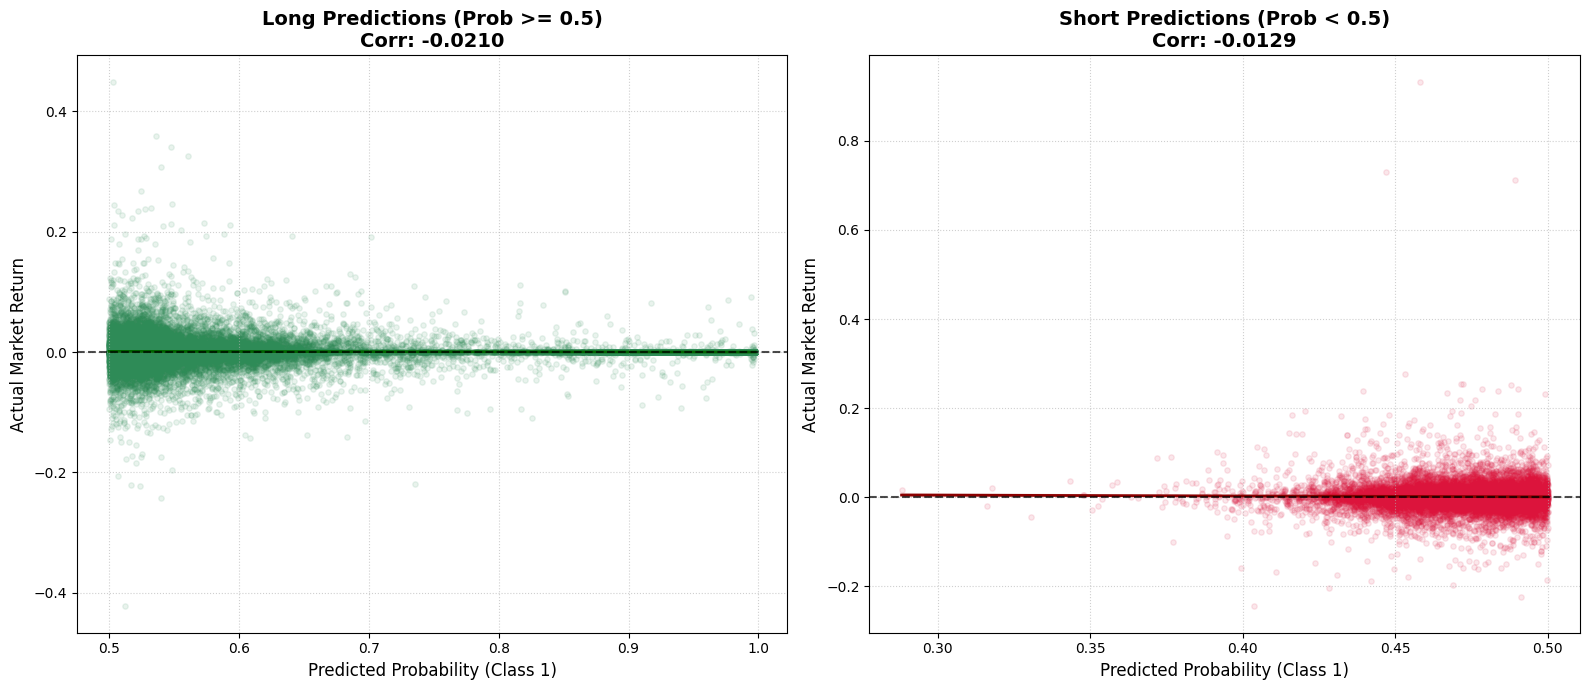

[방향성(Long/Short) 분리 상관관계 분석 결과]
Long 예측 구간 (데이터 38811개) | 상관계수: -0.0210 (p-value: 3.5517e-05)
Short 예측 구간 (데이터 15909개) | 상관계수: -0.0129 (p-value: 1.0280e-01)
------------------------------------------------------------
[그래프 해석 가이드]
1. 왼쪽 그래프 (Long): 추세선이 '우상향(양수)'해야 정상입니다. 확률이 0.5에서 1.0으로 갈수록 실제 수익률도 커짐을 의미합니다.
2. 오른쪽 그래프 (Short): 추세선이 '우상향(양수)'해야 정상입니다. 확률이 0.5에서 0.0(왼쪽)으로 갈수록, 실제 수익률이 음수 방향으로 커짐(하락폭 증가)을 의미하므로 숏 전략에 부합합니다.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("[추가 분석] 롱/숏 예측 방향별 피어슨 상관계수 분석 시작...\n")

# 1. 기준점 0.5를 기준으로 전체 예측 데이터를 롱(상승)과 숏(하락) 예측으로 분리
long_eval = eval_df[eval_df['predict_prob'] >= 0.5].copy()
short_eval = eval_df[eval_df['predict_prob'] < 0.5].copy()

# 2. 피어슨 상관계수 계산
corr_long, p_long = pearsonr(long_eval['predict_prob'], long_eval['actual_target_return'])
corr_short, p_short = pearsonr(short_eval['predict_prob'], short_eval['actual_target_return'])

# 3. 시각화 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 롱(Long) 그래프 세팅
sns.regplot(
    x='predict_prob', y='actual_target_return', data=long_eval,
    scatter_kws={'alpha': 0.1, 's': 15, 'color': 'seagreen'},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title(f'Long Predictions (Prob >= 0.5)\nCorr: {corr_long:.4f}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Probability (Class 1)', fontsize=12)
axes[0].set_ylabel('Actual Market Return', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 숏(Short) 그래프 세팅
sns.regplot(
    x='predict_prob', y='actual_target_return', data=short_eval,
    scatter_kws={'alpha': 0.1, 's': 15, 'color': 'crimson'},
    line_kws={'color': 'darkred', 'linewidth': 2},
    ax=axes[1]
)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title(f'Short Predictions (Prob < 0.5)\nCorr: {corr_short:.4f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Probability (Class 1)', fontsize=12)
axes[1].set_ylabel('Actual Market Return', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 결과 요약 출력
print("============================================================")
print("[방향성(Long/Short) 분리 상관관계 분석 결과]")
print(f"Long 예측 구간 (데이터 {len(long_eval)}개) | 상관계수: {corr_long:.4f} (p-value: {p_long:.4e})")
print(f"Short 예측 구간 (데이터 {len(short_eval)}개) | 상관계수: {corr_short:.4f} (p-value: {p_short:.4e})")
print("------------------------------------------------------------")
print("[그래프 해석 가이드]")
print("1. 왼쪽 그래프 (Long): 추세선이 '우상향(양수)'해야 정상입니다. 확률이 0.5에서 1.0으로 갈수록 실제 수익률도 커짐을 의미합니다.")
print("2. 오른쪽 그래프 (Short): 추세선이 '우상향(양수)'해야 정상입니다. 확률이 0.5에서 0.0(왼쪽)으로 갈수록, 실제 수익률이 음수 방향으로 커짐(하락폭 증가)을 의미하므로 숏 전략에 부합합니다.")
print("============================================================")

# L1 규제 넣어서 다시

In [10]:
import pandas as pd
import numpy as np

print("[Cell 1] 90일 시퀀스 데이터 및 실제 수익률 로드 시작...")

# 1. 90일 데이터 불러오기 
# (이 데이터의 'target' 컬럼에는 이미 과거 전처리 과정에서 만들어둔 0과 1 분류 정답지가 들어있습니다)
seq_file_path = './processed_sequences/train_data_seq_90d.csv'
df = pd.read_csv(seq_file_path)
df['target_date'] = pd.to_datetime(df['target_date'])

# 2. 실제 수익률 데이터 불러오기
# (학습에는 쓰지 않지만, 셀 3의 누적 수익률 계산과 셀 4의 상관계수 분석을 위해 필요합니다)
returns_file_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 3. 데이터 병합 (분류용 정답지와 실제 수익률을 한 곳에 모음)
merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
initial_len = len(merged_df)
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)

print("데이터 로드 및 병합 완료!")
print(f"총 데이터 개수: {len(merged_df)} 개")
print("\n[병합된 데이터 핵심 컬럼 미리보기]")
display(merged_df[['target_date', 'ticker', 'split_id', 'dataset_type', 'target', 'actual_target_return']].head())

[Cell 1] 90일 시퀀스 데이터 및 실제 수익률 로드 시작...
데이터 로드 및 병합 완료!
총 데이터 개수: 186480 개

[병합된 데이터 핵심 컬럼 미리보기]


,target_date,ticker,split_id,dataset_type,target,actual_target_return
0,2021-07-08,NVDA,1,Train,0,-0.023022
1,2021-07-09,NVDA,1,Train,0,0.007411
2,2021-07-10,NVDA,1,Train,1,0.000000
3,2021-07-11,NVDA,1,Train,1,0.000000
4,2021-07-12,NVDA,1,Train,1,0.023055


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

print("[Cell 2] L1 규제가 적용된 90일 분류(Classification) 모델 학습 시작...")

seq_length = 90
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 40 

# 🚨 L1 규제 강도 설정 (이 값이 클수록 모델이 더 많은 가중치를 0으로 만듭니다)
L1_LAMBDA = 1e-4 

all_test_results = []

class ClassificationLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(ClassificationLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=0.2) # 노이즈 방어를 위해 드롭아웃도 0.2로 상향
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 예측 진행 중 ---")
    
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['target'].values, dtype=torch.long)
    
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test = torch.tensor(test_df['target'].values, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
    
    model = ClassificationLSTM(input_size=1, hidden_size=25)
    criterion = nn.CrossEntropyLoss()
    # Weight Decay(L2 규제)도 미세하게 추가하여 극단적인 가중치 튀는 현상 이중 방어
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            # 기본 분류 손실(CrossEntropy) 계산
            base_loss = criterion(outputs, batch_y)
            
            # 🚨 L1 규제 (Lasso Penalty) 계산 및 추가
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = base_loss + L1_LAMBDA * l1_norm
            
            loss.backward()
            optimizer.step()
            
    model.eval()
    split_probs = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            outputs = model(batch_X)
            probs = F.softmax(outputs, dim=1)
            prob_of_1 = probs[:, 1].cpu().numpy()
            split_probs.extend(prob_of_1)
            
    test_df = test_df.copy()
    test_df['predict_prob'] = split_probs
    all_test_results.append(test_df)

total_test_results = pd.concat(all_test_results).reset_index(drop=True)

print("\n학습 및 확률 예측 완료!")
sample_date = total_test_results['target_date'].unique()[0]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[Cell 2] L1 규제가 적용된 90일 분류(Classification) 모델 학습 시작...
--- [Split 1] 학습 및 예측 진행 중 ---
--- [Split 2] 학습 및 예측 진행 중 ---
--- [Split 3] 학습 및 예측 진행 중 ---
--- [Split 4] 학습 및 예측 진행 중 ---
--- [Split 5] 학습 및 예측 진행 중 ---
--- [Split 6] 학습 및 예측 진행 중 ---
--- [Split 7] 학습 및 예측 진행 중 ---
--- [Split 8] 학습 및 예측 진행 중 ---
--- [Split 9] 학습 및 예측 진행 중 ---

학습 및 확률 예측 완료!


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-09,KO,1,0.000000,0.619759
1,2022-07-09,CAT,1,0.000000,0.618723
2,2022-07-09,CVX,1,0.000000,0.618568
3,2022-07-09,PG,1,0.000000,0.618384
4,2022-07-09,ABBV,1,0.000000,0.616807
5,2022-07-09,USDC-USD,0,0.000268,0.616734
6,2022-07-09,JNJ,1,0.000000,0.616527
7,2022-07-09,XOM,1,0.000000,0.616452
8,2022-07-09,DOGE-USD,1,0.003682,0.615296
9,2022-07-09,ADA-USD,1,0.024500,0.615115


In [12]:
print("[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]")
sample_date = total_test_results['target_date'].unique()[10]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[확인용: 첫 번째 날짜의 종목별 상회 확률 랭킹 (내림차순)]


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-19,UNH,0,0.027110,0.620922
1,2022-07-19,GOOGL,1,0.043841,0.619703
2,2022-07-19,JPM,0,0.024778,0.619696
3,2022-07-19,PG,0,0.005094,0.619691
4,2022-07-19,KO,0,0.014274,0.619575
5,2022-07-19,AAPL,0,0.026722,0.619103
6,2022-07-19,BRK-B,0,0.026388,0.618926
7,2022-07-19,COST,0,0.007612,0.618691
8,2022-07-19,LLY,0,0.013768,0.618396
9,2022-07-19,MSFT,0,0.020767,0.618293


[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...



c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


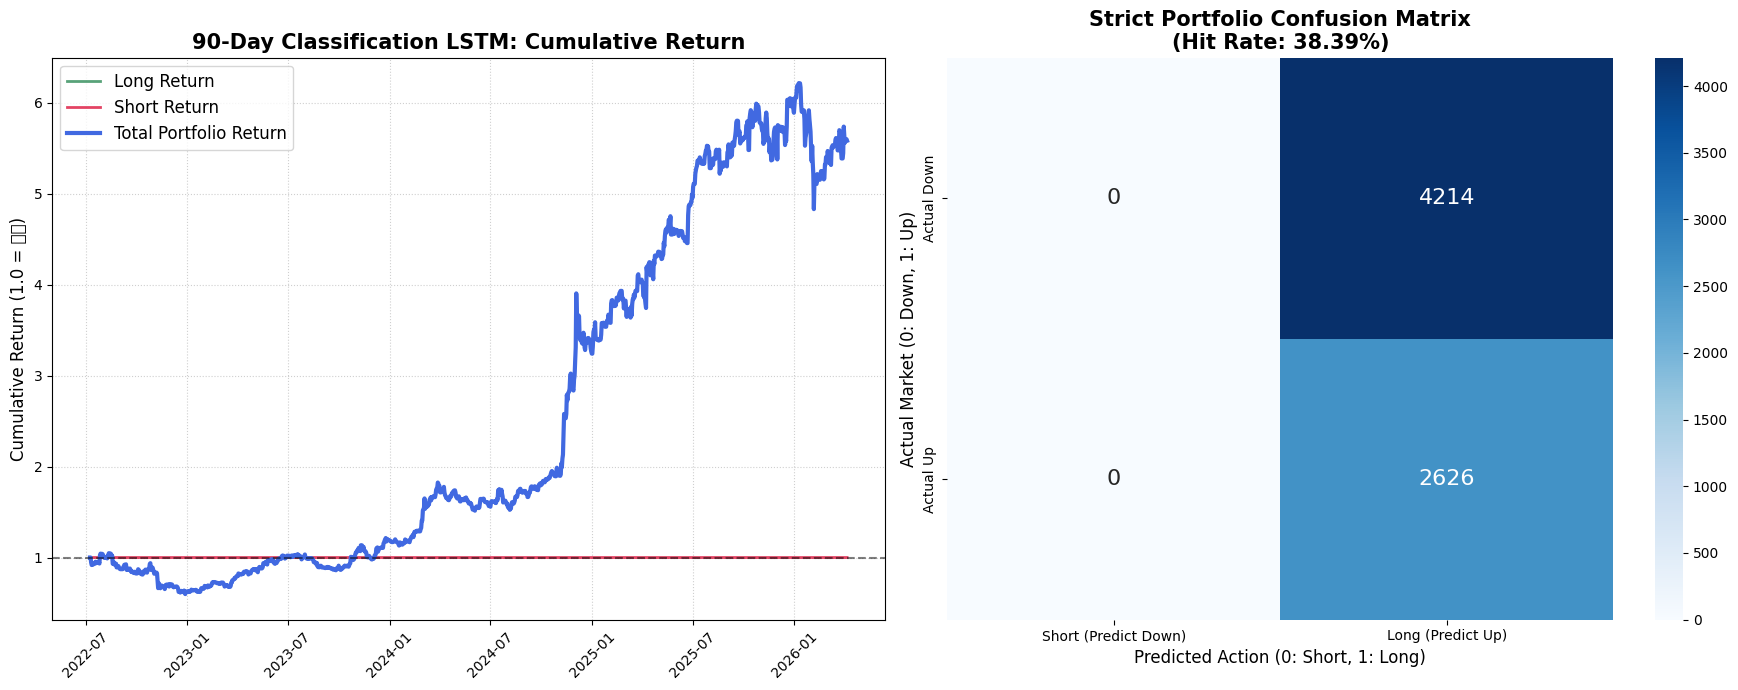

[엄격한 조건부 포트폴리오 백테스트 요약]
총 거래(포지션 진입) 횟수: 6840 건
 - Long(매수) 진입 횟수 : 6840 건
 - Short(공매도) 진입 횟수: 0 건
------------------------------------------------------------
Long 포지션 누적 성과 : 5.5817 (458.17%)
Short 포지션 누적 성과: 1.0000 (0.00%)
종합 포트폴리오 누적 성과: 5.5817 (458.17%)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import confusion_matrix, accuracy_score

print("[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...\n")

# 1. 🚨 모델의 '확신' 임계값(Threshold) 설정
# (주식 시장의 노이즈를 고려하여, 모델이 꽤 강하게 확신할 때만 진입합니다. 필요시 수치를 조정할 수 있습니다.)
LONG_THRESHOLD = 0.55  # 상회할 확률이 55% 이상일 때만 매수
SHORT_THRESHOLD = 0.45 # 상회할 확률이 45% 이하 (즉, 하회할 확률이 55% 이상)일 때만 공매도

portfolio_list = []

# 2. 날짜별 포지션 선정
for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 확률을 기준으로 내림차순 정렬 (1등 ~ 꼴등)
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # [조건 1] 상위 5개 중, 상승 확신이 충분히 큰(LONG_THRESHOLD 이상) 종목만 Long
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] >= LONG_THRESHOLD].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list.append(long_stocks)
        
    # [조건 2] 하위 5개 중, 하락 확신이 엄청나게 큰(SHORT_THRESHOLD 이하) 종목만 Short
    short_candidates = sorted_data.tail(5).copy()
    short_stocks = short_candidates[short_candidates['predict_prob'] <= SHORT_THRESHOLD].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list.append(short_stocks)

if not portfolio_list:
    print("설정한 임계값 조건을 만족하는 거래가 단 한 번도 발생하지 않았습니다. Threshold를 완화해주세요.")
else:
    final_portfolio = pd.concat(portfolio_list).reset_index(drop=True)
    
    # 3. 수익률 계산 (포트폴리오 비중 20% 고정)
    def calc_position_return(row):
        if row['position'] == 'Long':
            return row['actual_target_return'] * (1/5)
        elif row['position'] == 'Short':
            return row['actual_target_return'] * (-1/5)
        return 0

    final_portfolio['strategy_return'] = final_portfolio.apply(calc_position_return, axis=1)

    # 롱/숏 성과 분리
    long_pf = final_portfolio[final_portfolio['position'] == 'Long']
    short_pf = final_portfolio[final_portfolio['position'] == 'Short']

    daily_long = long_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'long_return'})
    daily_short = short_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'short_return'})
    daily_total = final_portfolio.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'total_return'})

    perf_df = pd.merge(daily_total, daily_long, on='target_date', how='left').fillna(0)
    perf_df = pd.merge(perf_df, daily_short, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')

    perf_df['cum_total'] = (1 + perf_df['total_return']).cumprod()
    perf_df['cum_long'] = (1 + perf_df['long_return']).cumprod()
    perf_df['cum_short'] = (1 + perf_df['short_return']).cumprod()

    # 4. 혼동 행렬(Confusion Matrix) 평가 준비
    # Pred: Long은 1(상승 예측), Short은 0(하락 예측)
    # Actual: 실제 수익률 > 0 이면 1(실제 상승), <= 0 이면 0(실제 하락)
    final_portfolio['pred_class'] = final_portfolio['position'].apply(lambda x: 1 if x == 'Long' else 0)
    final_portfolio['actual_class'] = final_portfolio['actual_target_return'].apply(lambda x: 1 if x > 0 else 0)

    cm = confusion_matrix(final_portfolio['actual_class'], final_portfolio['pred_class'])
    acc = accuracy_score(final_portfolio['actual_class'], final_portfolio['pred_class'])

    # 5. 결과 시각화
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 그래프 1: 롱/숏 분리 누적 수익률
    axes[0].plot(perf_df['target_date'], perf_df['cum_long'], label='Long Return', color='seagreen', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_short'], label='Short Return', color='crimson', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_total'], label='Total Portfolio Return', color='royalblue', linewidth=3)
    axes[0].axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

    axes[0].set_title('90-Day Classification LSTM: Cumulative Return', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    axes[0].legend(fontsize=12, loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].tick_params(axis='x', rotation=45)

    # 그래프 2: 혼동 행렬
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16})
    axes[1].set_title(f'Strict Portfolio Confusion Matrix\n(Hit Rate: {acc*100:.2f}%)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Predicted Action (0: Short, 1: Long)', fontsize=12)
    axes[1].set_ylabel('Actual Market (0: Down, 1: Up)', fontsize=12)
    axes[1].set_xticklabels(['Short (Predict Down)', 'Long (Predict Up)'])
    axes[1].set_yticklabels(['Actual Down', 'Actual Up'])

    plt.tight_layout()
    plt.show()

    # 최종 결과 요약 출력
    print("="*60)
    print("[엄격한 조건부 포트폴리오 백테스트 요약]")
    print(f"총 거래(포지션 진입) 횟수: {len(final_portfolio)} 건")
    print(f" - Long(매수) 진입 횟수 : {len(long_pf)} 건")
    print(f" - Short(공매도) 진입 횟수: {len(short_pf)} 건")
    print("-" * 60)
    print(f"Long 포지션 누적 성과 : {perf_df['cum_long'].iloc[-1]:.4f} ({(perf_df['cum_long'].iloc[-1]-1)*100:.2f}%)")
    print(f"Short 포지션 누적 성과: {perf_df['cum_short'].iloc[-1]:.4f} ({(perf_df['cum_short'].iloc[-1]-1)*100:.2f}%)")
    print(f"종합 포트폴리오 누적 성과: {perf_df['cum_total'].iloc[-1]:.4f} ({(perf_df['cum_total'].iloc[-1]-1)*100:.2f}%)")
    print("="*60)

[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...



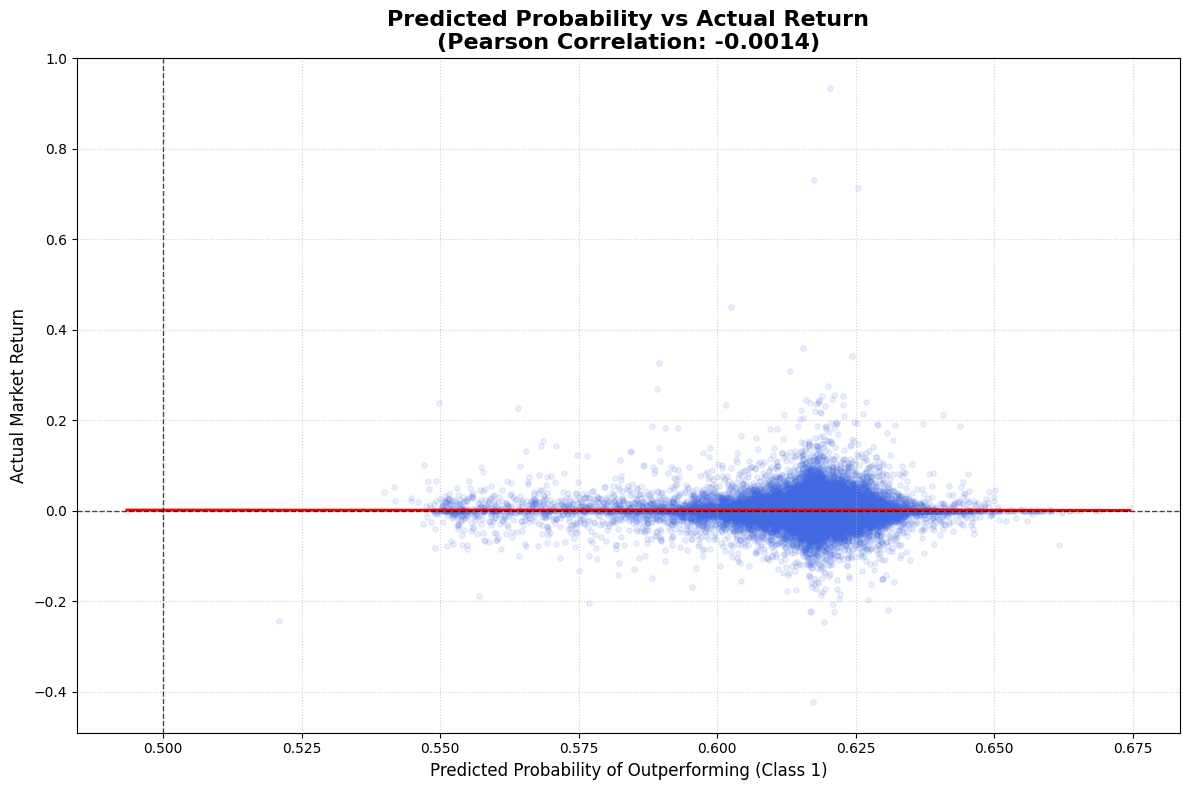

[예측 확률 기반 상관관계 분석 결과]
분석 데이터 개수: 54720 개
피어슨 상관계수(Correlation): -0.0014
p-value: 7.4329e-01
------------------------------------------------------------
[그래프 해석 가이드]
1. 추세선의 방향 (빨간 선):
   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.
   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)
2. 사분면 분포 (십자가 기준):
   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)
   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)
   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...\n")

# 1. 평가를 위한 데이터 정리 (결측치 제거)
# 전체 테스트 결과(total_test_results)를 사용하여 모델의 전반적인 예측력을 평가합니다.
eval_df = total_test_results.dropna(subset=['predict_prob', 'actual_target_return'])

# 2. 피어슨 상관계수 및 p-value 계산
corr, p_value = pearsonr(eval_df['predict_prob'], eval_df['actual_target_return'])

# 3. 산점도 및 추세선 시각화
plt.figure(figsize=(12, 8))

sns.regplot(
    x='predict_prob', 
    y='actual_target_return', 
    data=eval_df,
    scatter_kws={'alpha': 0.1, 's': 15, 'color': 'royalblue'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

# 기준선 그리기
# 가로선: 수익률 0 (수익/손실 경계)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
# 세로선: 확률 0.5 (상승/하락 예측 경계)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)

plt.title(f'Predicted Probability vs Actual Return\n(Pearson Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Probability of Outperforming (Class 1)', fontsize=12)
plt.ylabel('Actual Market Return', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 결과 요약 출력
print("============================================================")
print("[예측 확률 기반 상관관계 분석 결과]")
print(f"분석 데이터 개수: {len(eval_df)} 개")
print(f"피어슨 상관계수(Correlation): {corr:.4f}")
print(f"p-value: {p_value:.4e}")
print("------------------------------------------------------------")
print("[그래프 해석 가이드]")
print("1. 추세선의 방향 (빨간 선):")
print("   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.")
print("   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)")
print("2. 사분면 분포 (십자가 기준):")
print("   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)")
print("   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)")
print("   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.")
print("============================================================")

# L1 규제 입력 가중치는 Xavier 초기화, 은닉 가중치는 직교초기화를 적용하고,Forget Gate의 편향(Bias)을 강제로 1로 설정하는 퀀트 특화 초기화

In [15]:
import pandas as pd
import numpy as np

print("[Cell 1] 90일 시퀀스 데이터 및 실제 수익률 로드 시작...")

# 1. 90일 데이터 불러오기 
# (이 데이터의 'target' 컬럼에는 이미 과거 전처리 과정에서 만들어둔 0과 1 분류 정답지가 들어있습니다)
seq_file_path = './processed_sequences/train_data_seq_90d.csv'
df = pd.read_csv(seq_file_path)
df['target_date'] = pd.to_datetime(df['target_date'])

# 2. 실제 수익률 데이터 불러오기
# (학습에는 쓰지 않지만, 셀 3의 누적 수익률 계산과 셀 4의 상관계수 분석을 위해 필요합니다)
returns_file_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 3. 데이터 병합 (분류용 정답지와 실제 수익률을 한 곳에 모음)
merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
initial_len = len(merged_df)
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)

print("데이터 로드 및 병합 완료!")
print(f"총 데이터 개수: {len(merged_df)} 개")
print("\n[병합된 데이터 핵심 컬럼 미리보기]")
display(merged_df[['target_date', 'ticker', 'split_id', 'dataset_type', 'target', 'actual_target_return']].head())

[Cell 1] 90일 시퀀스 데이터 및 실제 수익률 로드 시작...
데이터 로드 및 병합 완료!
총 데이터 개수: 186480 개

[병합된 데이터 핵심 컬럼 미리보기]


,target_date,ticker,split_id,dataset_type,target,actual_target_return
0,2021-07-08,NVDA,1,Train,0,-0.023022
1,2021-07-09,NVDA,1,Train,0,0.007411
2,2021-07-10,NVDA,1,Train,1,0.000000
3,2021-07-11,NVDA,1,Train,1,0.000000
4,2021-07-12,NVDA,1,Train,1,0.023055


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np

print("[Cell 2] 가중치 초기화 및 LayerNorm이 적용된 강력한 분류 모델 학습 시작...")

seq_length = 90
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 40 

L1_LAMBDA = 1e-4  

all_test_results = []

class ClassificationLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, num_layers=1):
        super(ClassificationLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # 🚨 추가됨: 은닉 상태 정규화 (Internal Covariate Shift 방지)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(p=0.3) # 노이즈 방어를 위해 드롭아웃 강화
        self.fc = nn.Linear(hidden_size, 2)
        
        # 🚨 추가됨: 퀀트 시계열 특화 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                # Forget Gate Bias를 1로 강제 세팅하여 긴 시퀀스(90일)의 앞부분 기억을 보호
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # 마지막 시점 은닉 상태 추출
        out = lstm_out[:, -1, :]
        
        # 선형 계층(fc) 통과 전에 LayerNorm으로 데이터 스케일 재정렬
        out = self.layer_norm(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 예측 진행 중 ---")
    
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['target'].values, dtype=torch.long)
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, torch.zeros(len(X_test))), batch_size=256, shuffle=False)
    
    model = ClassificationLSTM(input_size=1, hidden_size=25)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            base_loss = criterion(outputs, batch_y)
            
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = base_loss + L1_LAMBDA * l1_norm
            
            loss.backward()
            
            # 🚨 추가됨: 기울기 폭발(Gradient Exploding) 방지용 클리핑
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
    model.eval()
    split_probs = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            outputs = model(batch_X)
            probs = F.softmax(outputs, dim=1)
            prob_of_1 = probs[:, 1].cpu().numpy()
            split_probs.extend(prob_of_1)
            
    test_df = test_df.copy()
    test_df['predict_prob'] = split_probs
    all_test_results.append(test_df)

total_test_results = pd.concat(all_test_results).reset_index(drop=True)

print("\n학습 및 확률 예측 완료!")
sample_date = total_test_results['target_date'].unique()[0]
sample_daily_data = total_test_results[total_test_results['target_date'] == sample_date]
sample_sorted = sample_daily_data.sort_values(by='predict_prob', ascending=False).reset_index(drop=True)

display(sample_sorted[['target_date', 'ticker', 'target', 'actual_target_return', 'predict_prob']])

[Cell 2] 가중치 초기화 및 LayerNorm이 적용된 강력한 분류 모델 학습 시작...
--- [Split 1] 학습 및 예측 진행 중 ---
--- [Split 2] 학습 및 예측 진행 중 ---
--- [Split 3] 학습 및 예측 진행 중 ---
--- [Split 4] 학습 및 예측 진행 중 ---
--- [Split 5] 학습 및 예측 진행 중 ---
--- [Split 6] 학습 및 예측 진행 중 ---
--- [Split 7] 학습 및 예측 진행 중 ---
--- [Split 8] 학습 및 예측 진행 중 ---
--- [Split 9] 학습 및 예측 진행 중 ---

학습 및 확률 예측 완료!


,target_date,ticker,target,actual_target_return,predict_prob
0,2022-07-09,XOM,1,0.000000,0.656879
1,2022-07-09,CAT,1,0.000000,0.651010
2,2022-07-09,KO,1,0.000000,0.649771
3,2022-07-09,JNJ,1,0.000000,0.647661
4,2022-07-09,AMZN,1,0.000000,0.646669
5,2022-07-09,MSFT,1,0.000000,0.644284
6,2022-07-09,CVX,1,0.000000,0.643832
7,2022-07-09,PG,1,0.000000,0.643405
8,2022-07-09,NFLX,1,0.000000,0.642494
9,2022-07-09,PLTR,1,0.000000,0.642001


[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...



c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


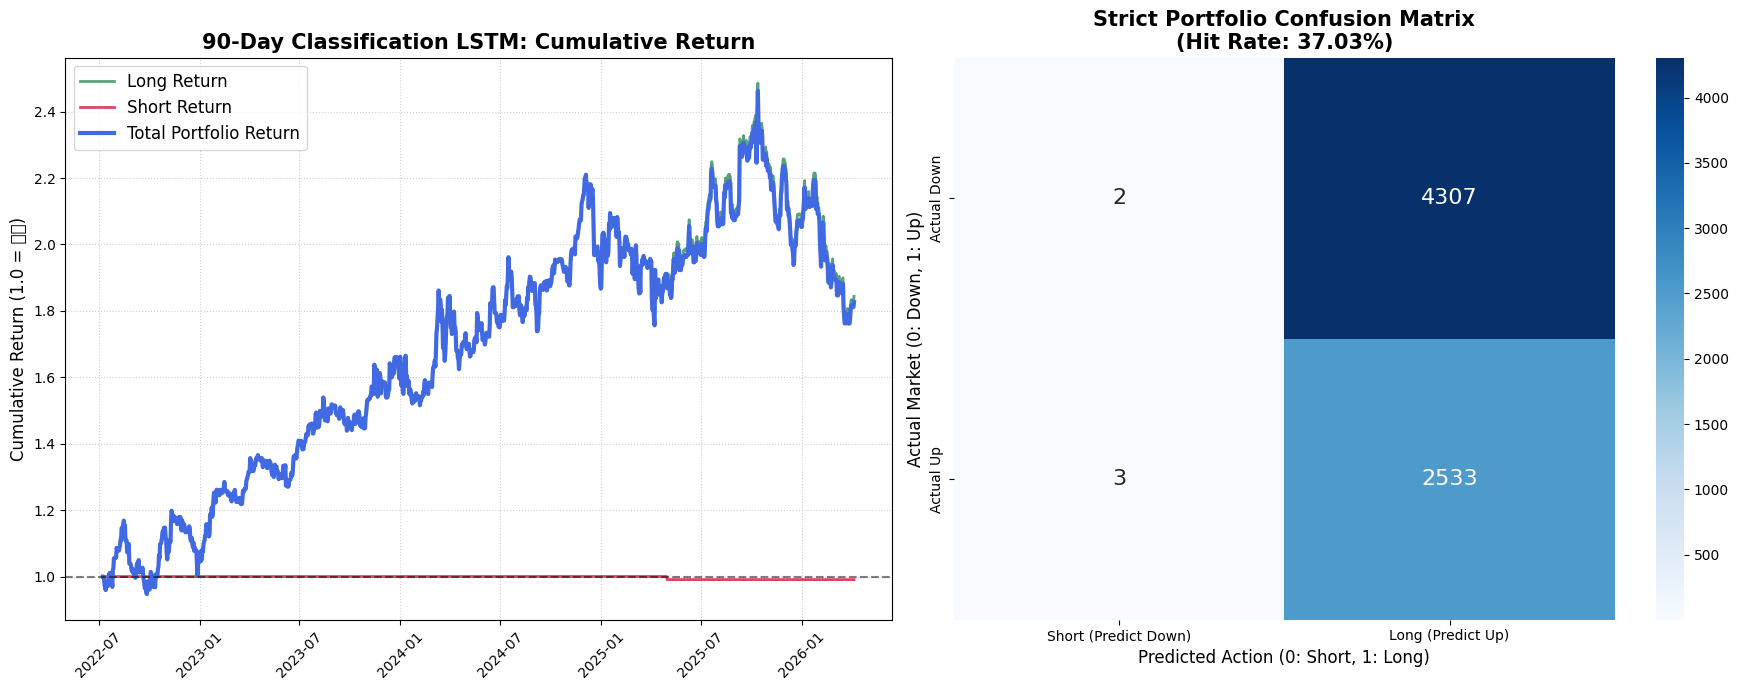

[엄격한 조건부 포트폴리오 백테스트 요약]
총 거래(포지션 진입) 횟수: 6845 건
 - Long(매수) 진입 횟수 : 6840 건
 - Short(공매도) 진입 횟수: 5 건
------------------------------------------------------------
Long 포지션 누적 성과 : 1.8437 (84.37%)
Short 포지션 누적 성과: 0.9908 (-0.92%)
종합 포트폴리오 누적 성과: 1.8266 (82.66%)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import confusion_matrix, accuracy_score

print("[Cell 3] 확률 기반 엄격한 조건부 롱/숏 포트폴리오 백테스트 및 시각화 시작...\n")

# 1. 🚨 모델의 '확신' 임계값(Threshold) 설정
# (주식 시장의 노이즈를 고려하여, 모델이 꽤 강하게 확신할 때만 진입합니다. 필요시 수치를 조정할 수 있습니다.)
LONG_THRESHOLD = 0.55  # 상회할 확률이 55% 이상일 때만 매수
SHORT_THRESHOLD = 0.45 # 상회할 확률이 45% 이하 (즉, 하회할 확률이 55% 이상)일 때만 공매도

portfolio_list = []

# 2. 날짜별 포지션 선정
for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 확률을 기준으로 내림차순 정렬 (1등 ~ 꼴등)
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # [조건 1] 상위 5개 중, 상승 확신이 충분히 큰(LONG_THRESHOLD 이상) 종목만 Long
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] >= LONG_THRESHOLD].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list.append(long_stocks)
        
    # [조건 2] 하위 5개 중, 하락 확신이 엄청나게 큰(SHORT_THRESHOLD 이하) 종목만 Short
    short_candidates = sorted_data.tail(5).copy()
    short_stocks = short_candidates[short_candidates['predict_prob'] <= SHORT_THRESHOLD].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list.append(short_stocks)

if not portfolio_list:
    print("설정한 임계값 조건을 만족하는 거래가 단 한 번도 발생하지 않았습니다. Threshold를 완화해주세요.")
else:
    final_portfolio = pd.concat(portfolio_list).reset_index(drop=True)
    
    # 3. 수익률 계산 (포트폴리오 비중 20% 고정)
    def calc_position_return(row):
        if row['position'] == 'Long':
            return row['actual_target_return'] * (1/5)
        elif row['position'] == 'Short':
            return row['actual_target_return'] * (-1/5)
        return 0

    final_portfolio['strategy_return'] = final_portfolio.apply(calc_position_return, axis=1)

    # 롱/숏 성과 분리
    long_pf = final_portfolio[final_portfolio['position'] == 'Long']
    short_pf = final_portfolio[final_portfolio['position'] == 'Short']

    daily_long = long_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'long_return'})
    daily_short = short_pf.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'short_return'})
    daily_total = final_portfolio.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'total_return'})

    perf_df = pd.merge(daily_total, daily_long, on='target_date', how='left').fillna(0)
    perf_df = pd.merge(perf_df, daily_short, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')

    perf_df['cum_total'] = (1 + perf_df['total_return']).cumprod()
    perf_df['cum_long'] = (1 + perf_df['long_return']).cumprod()
    perf_df['cum_short'] = (1 + perf_df['short_return']).cumprod()

    # 4. 혼동 행렬(Confusion Matrix) 평가 준비
    # Pred: Long은 1(상승 예측), Short은 0(하락 예측)
    # Actual: 실제 수익률 > 0 이면 1(실제 상승), <= 0 이면 0(실제 하락)
    final_portfolio['pred_class'] = final_portfolio['position'].apply(lambda x: 1 if x == 'Long' else 0)
    final_portfolio['actual_class'] = final_portfolio['actual_target_return'].apply(lambda x: 1 if x > 0 else 0)

    cm = confusion_matrix(final_portfolio['actual_class'], final_portfolio['pred_class'])
    acc = accuracy_score(final_portfolio['actual_class'], final_portfolio['pred_class'])

    # 5. 결과 시각화
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 그래프 1: 롱/숏 분리 누적 수익률
    axes[0].plot(perf_df['target_date'], perf_df['cum_long'], label='Long Return', color='seagreen', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_short'], label='Short Return', color='crimson', linewidth=2, alpha=0.8)
    axes[0].plot(perf_df['target_date'], perf_df['cum_total'], label='Total Portfolio Return', color='royalblue', linewidth=3)
    axes[0].axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

    axes[0].set_title('90-Day Classification LSTM: Cumulative Return', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    axes[0].legend(fontsize=12, loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].tick_params(axis='x', rotation=45)

    # 그래프 2: 혼동 행렬
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16})
    axes[1].set_title(f'Strict Portfolio Confusion Matrix\n(Hit Rate: {acc*100:.2f}%)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Predicted Action (0: Short, 1: Long)', fontsize=12)
    axes[1].set_ylabel('Actual Market (0: Down, 1: Up)', fontsize=12)
    axes[1].set_xticklabels(['Short (Predict Down)', 'Long (Predict Up)'])
    axes[1].set_yticklabels(['Actual Down', 'Actual Up'])

    plt.tight_layout()
    plt.show()

    # 최종 결과 요약 출력
    print("="*60)
    print("[엄격한 조건부 포트폴리오 백테스트 요약]")
    print(f"총 거래(포지션 진입) 횟수: {len(final_portfolio)} 건")
    print(f" - Long(매수) 진입 횟수 : {len(long_pf)} 건")
    print(f" - Short(공매도) 진입 횟수: {len(short_pf)} 건")
    print("-" * 60)
    print(f"Long 포지션 누적 성과 : {perf_df['cum_long'].iloc[-1]:.4f} ({(perf_df['cum_long'].iloc[-1]-1)*100:.2f}%)")
    print(f"Short 포지션 누적 성과: {perf_df['cum_short'].iloc[-1]:.4f} ({(perf_df['cum_short'].iloc[-1]-1)*100:.2f}%)")
    print(f"종합 포트폴리오 누적 성과: {perf_df['cum_total'].iloc[-1]:.4f} ({(perf_df['cum_total'].iloc[-1]-1)*100:.2f}%)")
    print("="*60)

[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...



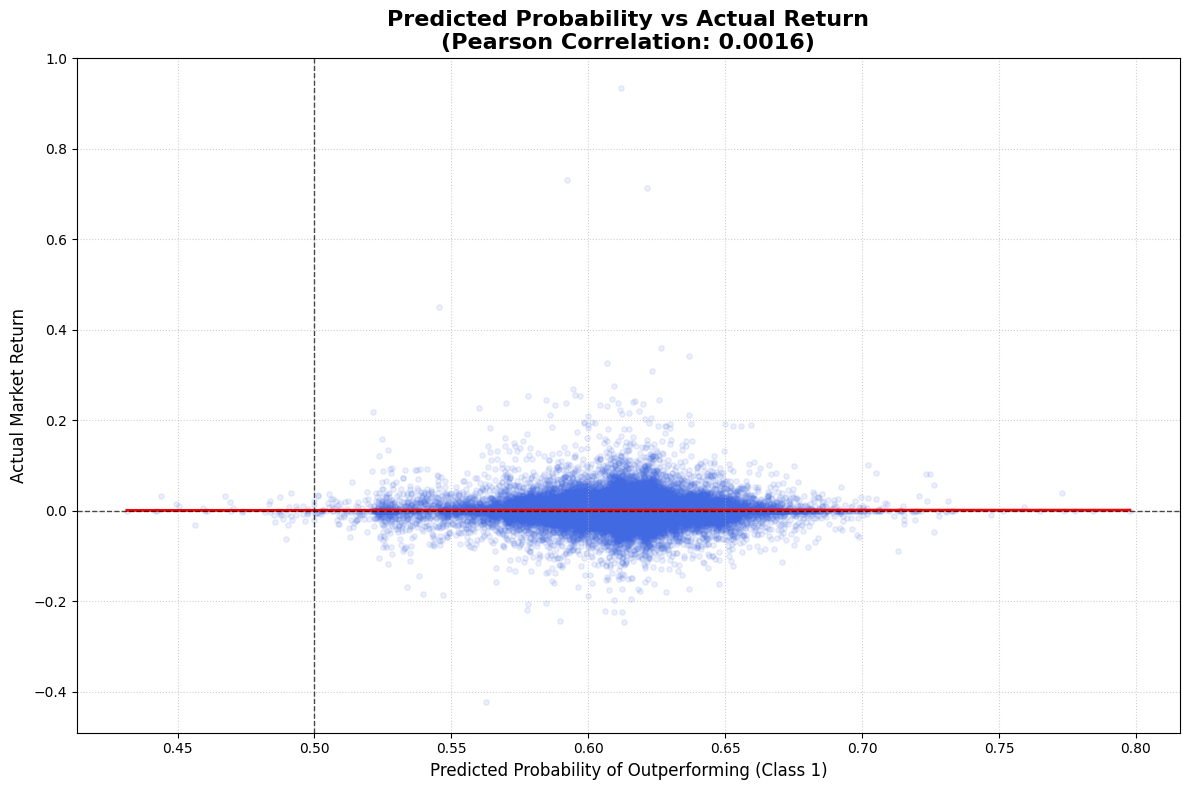

[예측 확률 기반 상관관계 분석 결과]
분석 데이터 개수: 54720 개
피어슨 상관계수(Correlation): 0.0016
p-value: 7.0604e-01
------------------------------------------------------------
[그래프 해석 가이드]
1. 추세선의 방향 (빨간 선):
   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.
   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)
2. 사분면 분포 (십자가 기준):
   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)
   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)
   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

print("[Cell 4] 예측 확률(확신도)과 실제 수익률 간의 피어슨 상관계수 분석 시작...\n")

# 1. 평가를 위한 데이터 정리 (결측치 제거)
# 전체 테스트 결과(total_test_results)를 사용하여 모델의 전반적인 예측력을 평가합니다.
eval_df = total_test_results.dropna(subset=['predict_prob', 'actual_target_return'])

# 2. 피어슨 상관계수 및 p-value 계산
corr, p_value = pearsonr(eval_df['predict_prob'], eval_df['actual_target_return'])

# 3. 산점도 및 추세선 시각화
plt.figure(figsize=(12, 8))

sns.regplot(
    x='predict_prob', 
    y='actual_target_return', 
    data=eval_df,
    scatter_kws={'alpha': 0.1, 's': 15, 'color': 'royalblue'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

# 기준선 그리기
# 가로선: 수익률 0 (수익/손실 경계)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1)
# 세로선: 확률 0.5 (상승/하락 예측 경계)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)

plt.title(f'Predicted Probability vs Actual Return\n(Pearson Correlation: {corr:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Probability of Outperforming (Class 1)', fontsize=12)
plt.ylabel('Actual Market Return', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 결과 요약 출력
print("============================================================")
print("[예측 확률 기반 상관관계 분석 결과]")
print(f"분석 데이터 개수: {len(eval_df)} 개")
print(f"피어슨 상관계수(Correlation): {corr:.4f}")
print(f"p-value: {p_value:.4e}")
print("------------------------------------------------------------")
print("[그래프 해석 가이드]")
print("1. 추세선의 방향 (빨간 선):")
print("   - 우상향(상관계수 양수): 모델이 상승을 강하게 확신할수록(확률 1에 근접), 실제 수익률도 더 높게 나왔음을 의미합니다. 아주 이상적인 결과입니다.")
print("   - 수평(상관계수 0 근접): 확신도와 수익률 크기 간에 뚜렷한 선형 관계가 없습니다. (단, 이 경우에도 방향만 맞춘다면 포트폴리오 수익은 날 수 있습니다)")
print("2. 사분면 분포 (십자가 기준):")
print("   - 1사분면(우측 상단): 상승 예측(>0.5) 후 실제 상승(>0) -> 적중 (Long 성공)")
print("   - 3사분면(좌측 하단): 하락 예측(<0.5) 후 실제 하락(<0) -> 적중 (Short 성공)")
print("   - 이 두 사분면에 점이 집중되어 있다면 분류 모델로서의 역할은 완벽하게 수행한 것입니다.")
print("============================================================")

## 제미나이가 스피어만 상관계수를 써야한다고 조언

[Cell 4] 일일 랭크 상관계수(Information Coefficient, IC) 분석 시작...



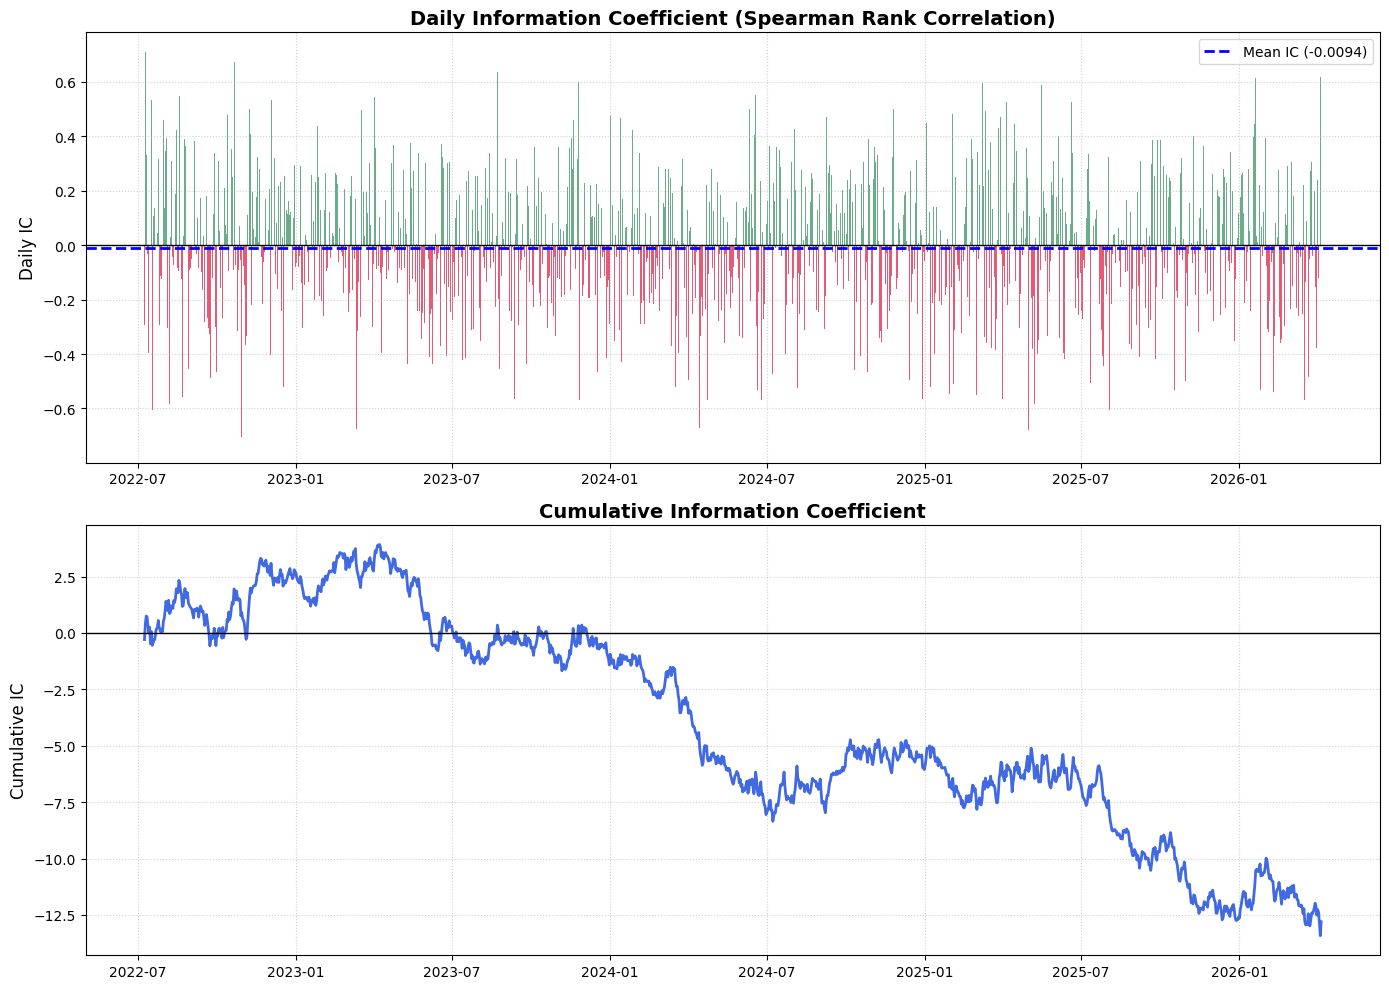

[랭크 기반 상관계수(IC) 분석 결과]
평균 일일 IC (Mean IC): -0.0094
양의 IC 달성 비율 (IC > 0 Hit Rate): 47.00%
------------------------------------------------------------
[결과 해석 가이드]
1. 분류 모델의 성능은 피어슨이 아닌 이 '평균 일일 IC'로 판단해야 합니다.
2. 퀀트 실무에서 평균 IC가 0.02 (2%) 이상이면 시장을 이길 수 있는 매우 훌륭한 시그널로 평가합니다.
3. 아래 누적 IC 그래프가 꾸준히 우상향한다면, 모델이 시장 상황과 무관하게 종목들의 순위를 지속적으로 잘 맞추고 있다는 강력한 증거입니다.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("[Cell 4] 일일 랭크 상관계수(Information Coefficient, IC) 분석 시작...\n")

# 결측치 제거
eval_df = total_test_results.dropna(subset=['predict_prob', 'actual_target_return']).copy()

daily_ic_list = []
daily_dates = []

# 전체 데이터를 섞지 않고, '매일매일(Date)' 그룹화하여 순위 상관계수를 계산
for date, daily_data in eval_df.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 확률 기반 랭킹과 실제 수익률 기반 랭킹 간의 스피어만 상관계수 계산
    ic, p_val = spearmanr(daily_data['predict_prob'], daily_data['actual_target_return'])
    
    # NaN 값이 나오는 경우 제외
    if not np.isnan(ic):
        daily_ic_list.append(ic)
        daily_dates.append(date)

# IC 데이터프레임 생성
ic_df = pd.DataFrame({'target_date': daily_dates, 'daily_IC': daily_ic_list})
ic_df['target_date'] = pd.to_datetime(ic_df['target_date'])

# 누적 IC (모델의 장기적 랭킹 예측력)
ic_df['cum_IC'] = ic_df['daily_IC'].cumsum()

# 평균 IC 산출
mean_ic = ic_df['daily_IC'].mean()
hit_rate = (ic_df['daily_IC'] > 0).mean() * 100

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. 일일 IC 막대 그래프
axes[0].bar(ic_df['target_date'], ic_df['daily_IC'], color=np.where(ic_df['daily_IC'] >= 0, 'seagreen', 'crimson'), alpha=0.7)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axhline(mean_ic, color='blue', linestyle='--', linewidth=2, label=f'Mean IC ({mean_ic:.4f})')
axes[0].set_title('Daily Information Coefficient (Spearman Rank Correlation)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Daily IC', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. 누적 IC 선 그래프
axes[1].plot(ic_df['target_date'], ic_df['cum_IC'], color='royalblue', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Cumulative Information Coefficient', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cumulative IC', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("============================================================")
print("[랭크 기반 상관계수(IC) 분석 결과]")
print("============================================================")
print(f"평균 일일 IC (Mean IC): {mean_ic:.4f}")
print(f"양의 IC 달성 비율 (IC > 0 Hit Rate): {hit_rate:.2f}%")
print("------------------------------------------------------------")
print("[결과 해석 가이드]")
print("1. 분류 모델의 성능은 피어슨이 아닌 이 '평균 일일 IC'로 판단해야 합니다.")
print("2. 퀀트 실무에서 평균 IC가 0.02 (2%) 이상이면 시장을 이길 수 있는 매우 훌륭한 시그널로 평가합니다.")
print("3. 아래 누적 IC 그래프가 꾸준히 우상향한다면, 모델이 시장 상황과 무관하게 종목들의 순위를 지속적으로 잘 맞추고 있다는 강력한 증거입니다.")
print("============================================================")

피어슨 상관계수의 선형성(Linearity) 한계
피어슨 상관계수는 두 변수가 완벽한 직선 관계를 가질 때 의미가 있습니다. 하지만 Softmax를 통과한 확률값은 0과 1 양극단으로 쏠리는 S자 곡선(Sigmoid 분포)을 띠며, 주가 수익률은 꼬리가 두꺼운(Fat-tail) 분포를 가집니다. 형태가 전혀 다른 두 분포를 선형 상관계수로 엮으면 값은 필연적으로 0에 수렴합니다.

[추가 분석] 엇박자 시그널을 이용한 리버스(Reverse) 전략 백테스트 시작...



C:\Users\skack\AppData\Local\Temp\ipykernel_17128\1108337862.py:80: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_17128\1108337862.py:80: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


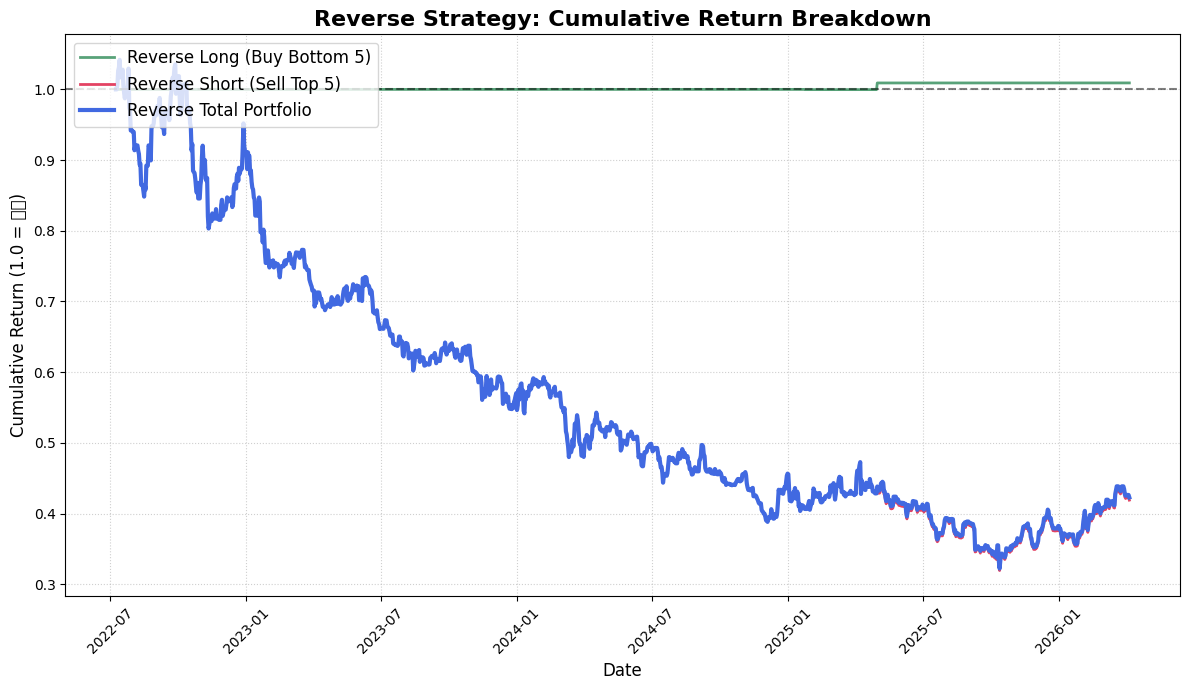

[리버스 전략 백테스트 성과]
Long(하위 매수) 누적 성과 : 1.0092
Short(상위 공매도) 누적 성과: 0.4191
종합 포트폴리오 누적 성과: 0.4229


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[추가 분석] 엇박자 시그널을 이용한 리버스(Reverse) 전략 백테스트 시작...\n")

portfolio_list_reverse = []

# 1. 🚨 리버스 전략을 위한 포지션 선정 (로직 180도 뒤집기)
for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    # 확률을 기준으로 내림차순 정렬 (1등: 상승 확신, 꼴등: 하락 확신)
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # [리버스 롱] 기존에는 Short을 쳤을 '꼴등 5개'를 ➡️ 매수(Long)
    # 조건: 하락 확신이 큰(확률이 낮은) 종목들
    long_candidates = sorted_data.tail(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] <= 0.45].copy()
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        portfolio_list_reverse.append(long_stocks)
        
    # [리버스 숏] 기존에는 Long을 쳤을 '1등 5개'를 ➡️ 공매도(Short)
    # 조건: 상승 확신이 큰(확률이 높은) 종목들
    short_candidates = sorted_data.head(5).copy()
    short_stocks = short_candidates[short_candidates['predict_prob'] >= 0.55].copy()
    if not short_stocks.empty:
        short_stocks['position'] = 'Short'
        portfolio_list_reverse.append(short_stocks)

if not portfolio_list_reverse:
    print("거래가 발생하지 않았습니다.")
else:
    rev_portfolio = pd.concat(portfolio_list_reverse).reset_index(drop=True)
    
    # 2. 수익률 계산
    def calc_rev_position_return(row):
        if row['position'] == 'Long':
            return row['actual_target_return'] * (1/5)
        elif row['position'] == 'Short':
            return row['actual_target_return'] * (-1/5)
        return 0

    rev_portfolio['strategy_return'] = rev_portfolio.apply(calc_rev_position_return, axis=1)

    # 3. 롱/숏 성과 분리
    long_rev = rev_portfolio[rev_portfolio['position'] == 'Long']
    short_rev = rev_portfolio[rev_portfolio['position'] == 'Short']

    daily_long_rev = long_rev.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'long_return'})
    daily_short_rev = short_rev.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'short_return'})
    daily_total_rev = rev_portfolio.groupby('target_date')['strategy_return'].sum().reset_index().rename(columns={'strategy_return': 'total_return'})

    perf_rev = pd.merge(daily_total_rev, daily_long_rev, on='target_date', how='left').fillna(0)
    perf_rev = pd.merge(perf_rev, daily_short_rev, on='target_date', how='left').fillna(0)
    perf_rev = perf_rev.sort_values('target_date')

    perf_rev['cum_total'] = (1 + perf_rev['total_return']).cumprod()
    perf_rev['cum_long'] = (1 + perf_rev['long_return']).cumprod()
    perf_rev['cum_short'] = (1 + perf_rev['short_return']).cumprod()

    # 4. 시각화
    plt.figure(figsize=(12, 7))
    plt.plot(perf_rev['target_date'], perf_rev['cum_long'], label='Reverse Long (Buy Bottom 5)', color='seagreen', linewidth=2, alpha=0.8)
    plt.plot(perf_rev['target_date'], perf_rev['cum_short'], label='Reverse Short (Sell Top 5)', color='crimson', linewidth=2, alpha=0.8)
    plt.plot(perf_rev['target_date'], perf_rev['cum_total'], label='Reverse Total Portfolio', color='royalblue', linewidth=3)
    plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

    plt.title('Reverse Strategy: Cumulative Return Breakdown', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("============================================================")
    print("[리버스 전략 백테스트 성과]")
    print("============================================================")
    print(f"Long(하위 매수) 누적 성과 : {perf_rev['cum_long'].iloc[-1]:.4f}")
    print(f"Short(상위 공매도) 누적 성과: {perf_rev['cum_short'].iloc[-1]:.4f}")
    print(f"종합 포트폴리오 누적 성과: {perf_rev['cum_total'].iloc[-1]:.4f}")
    print("============================================================")

[Cell 3 수정] 숏(Short) 포지션 폐기, Long-Only 전략 vs 시장 벤치마크 비교 시작...



C:\Users\skack\AppData\Local\Temp\ipykernel_17128\3777819414.py:63: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_17128\3777819414.py:63: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


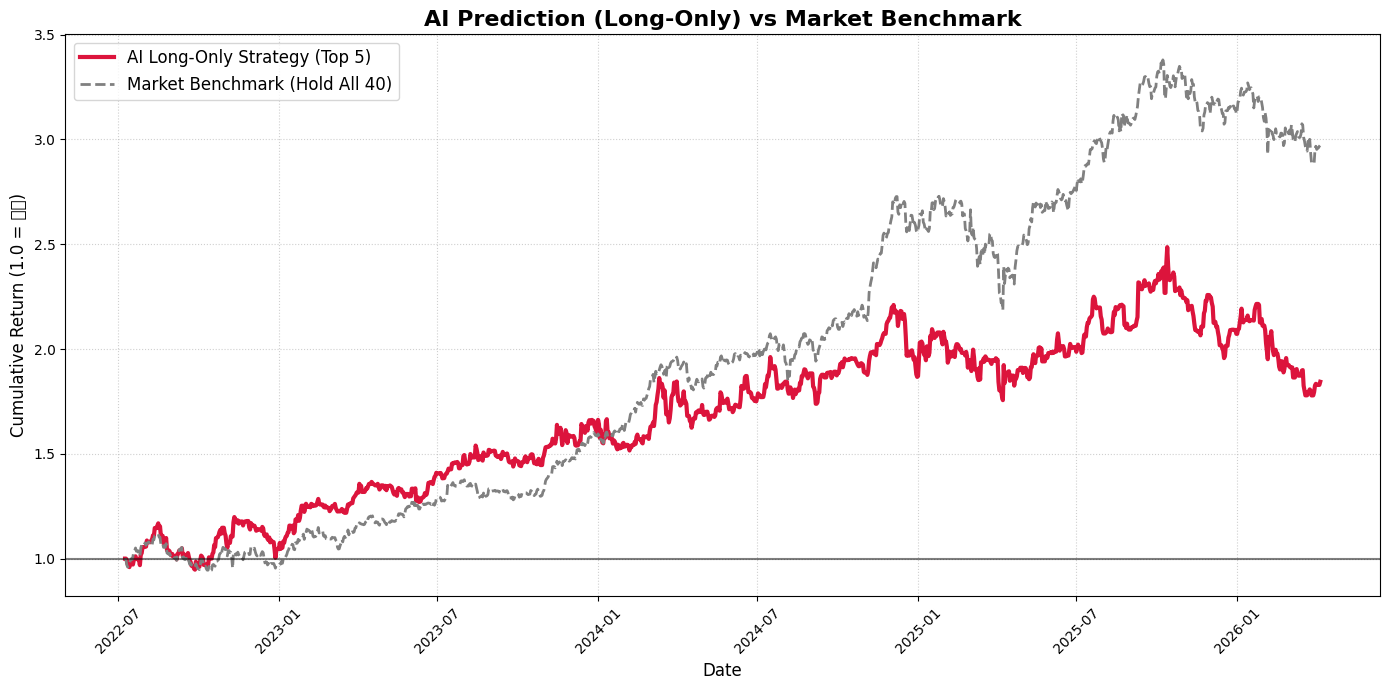

[Long-Only 전략 백테스트 최종 성과]
총 매수(Long) 진입 횟수: 6840 건
------------------------------------------------------------
단순 시장 보유(Benchmark) 누적 수익률 : 2.9724
AI 상위 5개 매수(Strategy) 누적 수익률: 1.8437
해석: AI 모델의 빨간 선(Strategy)이 회색 점선(Benchmark)을 뚫고 위에 있다면,
우리 모델이 오를 종목을 시장 평균보다 훨씬 압도적으로 잘 짚어냈다는 완벽한 증거입니다.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[Cell 3 수정] 숏(Short) 포지션 폐기, Long-Only 전략 vs 시장 벤치마크 비교 시작...\n")

portfolio_list_long = []

# 1. 포지션 선정: 숏(Short) 완전 폐기, 오직 확실한 롱(Long)만 잡는다.
for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10:
        continue
        
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # [조건] 상승 확신이 55% 이상인 상위 최대 5개 종목만 매수
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] >= 0.55].copy()
    
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        # 자금 관리를 위해 매일 5등분(20%) 비중으로 투자 (5개가 안 되면 현금 보유)
        long_stocks['weight'] = 1/5 
        portfolio_list_long.append(long_stocks)

if not portfolio_list_long:
    print("조건을 만족하는 거래가 단 한 번도 발생하지 않았습니다. Threshold를 완화해주세요.")
else:
    final_long_pf = pd.concat(portfolio_list_long).reset_index(drop=True)
    
    # 2. 전략 수익률 계산
    final_long_pf['strategy_return'] = final_long_pf['actual_target_return'] * final_long_pf['weight']
    daily_strategy = final_long_pf.groupby('target_date')['strategy_return'].sum().reset_index()
    
    # 3. 벤치마크(시장 평균) 수익률 계산
    # 우리가 타겟팅하는 40개(주식30+코인10) 전체를 매일 동일 비중으로 샀을 때의 수익률
    daily_benchmark = total_test_results.groupby('target_date')['actual_target_return'].mean().reset_index()
    daily_benchmark.rename(columns={'actual_target_return': 'benchmark_return'}, inplace=True)
    
    # 데이터 병합 및 누적 수익률 계산
    perf_df = pd.merge(daily_benchmark, daily_strategy, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')
    
    perf_df['cum_strategy'] = (1 + perf_df['strategy_return']).cumprod()
    perf_df['cum_benchmark'] = (1 + perf_df['benchmark_return']).cumprod()
    
    # 4. 시각화
    plt.figure(figsize=(14, 7))
    plt.plot(perf_df['target_date'], perf_df['cum_strategy'], label='AI Long-Only Strategy (Top 5)', color='crimson', linewidth=3)
    plt.plot(perf_df['target_date'], perf_df['cum_benchmark'], label='Market Benchmark (Hold All 40)', color='gray', linewidth=2, linestyle='--')
    plt.axhline(1.0, color='black', linestyle='-', alpha=0.5)
    
    plt.title('AI Prediction (Long-Only) vs Market Benchmark', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return (1.0 = 원금)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 5. 최종 결과 요약 출력
    print("="*60)
    print("[Long-Only 전략 백테스트 최종 성과]")
    print(f"총 매수(Long) 진입 횟수: {len(final_long_pf)} 건")
    print("-" * 60)
    print(f"단순 시장 보유(Benchmark) 누적 수익률 : {perf_df['cum_benchmark'].iloc[-1]:.4f}")
    print(f"AI 상위 5개 매수(Strategy) 누적 수익률: {perf_df['cum_strategy'].iloc[-1]:.4f}")
    print("="*60)
    print("해석: AI 모델의 빨간 선(Strategy)이 회색 점선(Benchmark)을 뚫고 위에 있다면,")
    print("우리 모델이 오를 종목을 시장 평균보다 훨씬 압도적으로 잘 짚어냈다는 완벽한 증거입니다.")

# 처음부터 다시

데이터: 90일 시퀀스

모델 (Robust Classification LSTM):

퀀트 전용 가중치 초기화 (Forget Gate Bias = 1.0, 직교 초기화)

은닉 상태 폭주 방지를 위한 LayerNorm 도입

과적합 이중 방패: Dropout(0.3), 옵티마이저 Weight Decay(L2)

학습 통제:

L1 정규화(Lasso)로 의미 없는 노이즈 날짜의 가중치 삭제

Gradient Clipping(max_norm=1.0)으로 시장 충격 시 기울기 폭발 방지

최종 매매 전략 (Strict Long-Only):

숏(Short) 포지션 영구 폐기.

모델이 상승을 55% 이상 확신하는 최상위(Top) 최대 5개 종목만 균등 매수.

찐찐최종마지막 LSTM 모델 및 Long-Only 백테스트 파이프라인 시작...

데이터 준비 완료 (총 186480행)
--- [Split 1/9] 학습 및 인퍼런스 중 ---
--- [Split 2/9] 학습 및 인퍼런스 중 ---
--- [Split 3/9] 학습 및 인퍼런스 중 ---
--- [Split 4/9] 학습 및 인퍼런스 중 ---
--- [Split 5/9] 학습 및 인퍼런스 중 ---
--- [Split 6/9] 학습 및 인퍼런스 중 ---
--- [Split 7/9] 학습 및 인퍼런스 중 ---
--- [Split 8/9] 학습 및 인퍼런스 중 ---
--- [Split 9/9] 학습 및 인퍼런스 중 ---

[학습 완료] 전략 평가를 시작합니다...



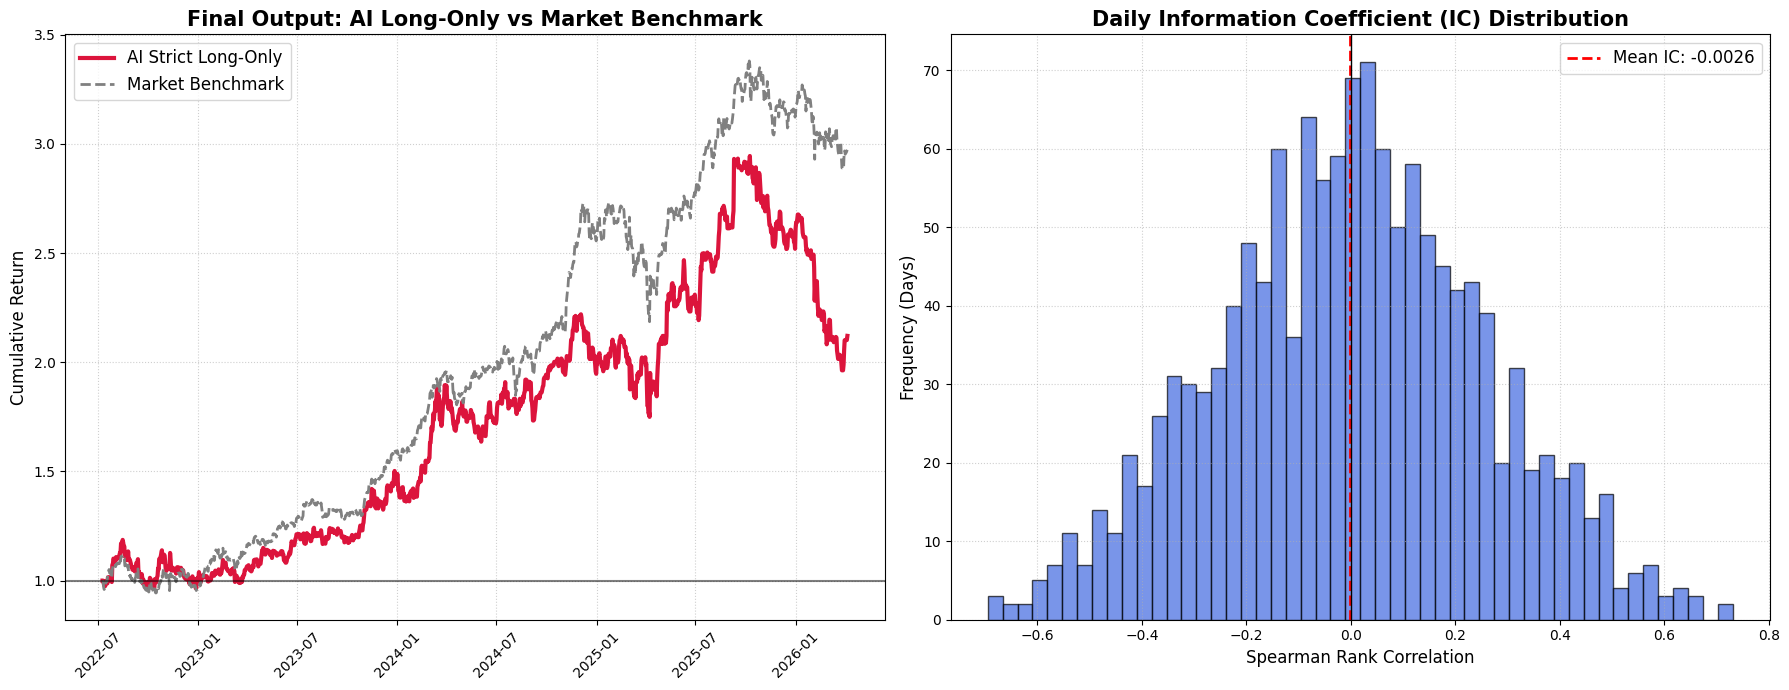

[FINAL MASTERPIECE: 전략 성과 요약]
총 분석 기간(일수): 1368 일
실제 Long 진입 횟수: 6840 종목 (기준: 상승확률 >= 55%)
------------------------------------------------------------
단순 시장 보유(Benchmark) 누적 수익률: 2.9724
AI Long-Only 전략 누적 수익률      : 2.1206
평균 일일 Information Coefficient  : -0.0026


In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

print("찐찐최종마지막 LSTM 모델 및 Long-Only 백테스트 파이프라인 시작...\n")

# ==========================================
# 1. 데이터 로드 및 병합 (정답지와 실제 수익률)
# ==========================================
seq_file_path = './processed_sequences/train_data_seq_90d.csv'
returns_file_path = '../../tests/data_/returns.csv'

df = pd.read_csv(seq_file_path)
df['target_date'] = pd.to_datetime(df['target_date'])

raw_returns = pd.read_csv(returns_file_path, index_col=0, parse_dates=True)
returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', value_name='actual_target_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

merged_df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
merged_df = merged_df.dropna(subset=['actual_target_return']).reset_index(drop=True)

print(f"데이터 준비 완료 (총 {len(merged_df)}행)")

# ==========================================
# 2. 최적화된 Quant 전용 LSTM 모델 정의
# ==========================================
class RobustQuantLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RobustQuantLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(hidden_size, 2)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0) # Forget Gate Bias = 1.0

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.layer_norm(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ==========================================
# 3. 모델 학습 및 예측 (모든 Split 순회)
# ==========================================
seq_length = 90
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]
unique_splits = sorted(merged_df['split_id'].unique())
num_epochs = 40
L1_LAMBDA = 1e-4

all_test_results = []

for split_id in unique_splits:
    print(f"--- [Split {split_id}/{len(unique_splits)}] 학습 및 인퍼런스 중 ---")
    
    split_df = merged_df[merged_df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0: continue
        
    X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(train_df['target'].values, dtype=torch.long)
    X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, torch.zeros(len(X_test))), batch_size=256, shuffle=False)
    
    model = RobustQuantLSTM(input_size=1, hidden_size=32)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5) # AdamW 도입
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            base_loss = criterion(outputs, batch_y)
            
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = base_loss + L1_LAMBDA * l1_norm
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
    model.eval()
    split_probs = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            probs = F.softmax(model(batch_X), dim=1)
            split_probs.extend(probs[:, 1].cpu().numpy())
            
    test_df = test_df.copy()
    test_df['predict_prob'] = split_probs
    all_test_results.append(test_df)

total_test_results = pd.concat(all_test_results).reset_index(drop=True)
print("\n[학습 완료] 전략 평가를 시작합니다...\n")

# ==========================================
# 4. Strict Long-Only 포트폴리오 백테스트
# ==========================================
LONG_THRESHOLD = 0.55
portfolio_list = []

for date, daily_data in total_test_results.groupby('target_date'):
    if len(daily_data) < 10: continue
        
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    long_candidates = sorted_data.head(5).copy()
    long_stocks = long_candidates[long_candidates['predict_prob'] >= LONG_THRESHOLD].copy()
    
    if not long_stocks.empty:
        long_stocks['position'] = 'Long'
        long_stocks['weight'] = 1 / 5 # 매일 5등분 비중
        portfolio_list.append(long_stocks)

if not portfolio_list:
    print("조건을 만족하는 거래가 없습니다. Threshold를 낮춰주세요.")
else:
    final_pf = pd.concat(portfolio_list).reset_index(drop=True)
    final_pf['strategy_return'] = final_pf['actual_target_return'] * final_pf['weight']
    
    daily_strategy = final_pf.groupby('target_date')['strategy_return'].sum().reset_index()
    
    # 벤치마크: 당일 전체 유니버스 동일비중 수익률
    daily_benchmark = total_test_results.groupby('target_date')['actual_target_return'].mean().reset_index()
    daily_benchmark.rename(columns={'actual_target_return': 'benchmark_return'}, inplace=True)
    
    perf_df = pd.merge(daily_benchmark, daily_strategy, on='target_date', how='left').fillna(0)
    perf_df = perf_df.sort_values('target_date')
    
    perf_df['cum_strategy'] = (1 + perf_df['strategy_return']).cumprod()
    perf_df['cum_benchmark'] = (1 + perf_df['benchmark_return']).cumprod()
    
    # Information Coefficient (IC) 계산
    ic_list = []
    for date, daily_data in total_test_results.groupby('target_date'):
        if len(daily_data) >= 10:
            ic, _ = spearmanr(daily_data['predict_prob'], daily_data['actual_target_return'])
            if not np.isnan(ic): ic_list.append(ic)
    mean_ic = np.mean(ic_list)
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # 누적 수익률 그래프
    axes[0].plot(perf_df['target_date'], perf_df['cum_strategy'], label='AI Strict Long-Only', color='crimson', linewidth=3)
    axes[0].plot(perf_df['target_date'], perf_df['cum_benchmark'], label='Market Benchmark', color='gray', linewidth=2, linestyle='--')
    axes[0].axhline(1.0, color='black', linestyle='-', alpha=0.5)
    axes[0].set_title('Final Output: AI Long-Only vs Market Benchmark', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Cumulative Return', fontsize=12)
    axes[0].legend(fontsize=12, loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].tick_params(axis='x', rotation=45)
    
    # IC 분포 히스토그램
    axes[1].hist(ic_list, bins=50, color='royalblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(mean_ic, color='red', linestyle='dashed', linewidth=2, label=f'Mean IC: {mean_ic:.4f}')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title('Daily Information Coefficient (IC) Distribution', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Spearman Rank Correlation', fontsize=12)
    axes[1].set_ylabel('Frequency (Days)', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    print("============================================================")
    print("[FINAL MASTERPIECE: 전략 성과 요약]")
    print(f"총 분석 기간(일수): {len(perf_df)} 일")
    print(f"실제 Long 진입 횟수: {len(final_pf)} 종목 (기준: 상승확률 >= 55%)")
    print("-" * 60)
    print(f"단순 시장 보유(Benchmark) 누적 수익률: {perf_df['cum_benchmark'].iloc[-1]:.4f}")
    print(f"AI Long-Only 전략 누적 수익률      : {perf_df['cum_strategy'].iloc[-1]:.4f}")
    print(f"평균 일일 Information Coefficient  : {mean_ic:.4f}")
    print("============================================================")

[추가 분석] 최종 모델의 분류 성능 평가 (Confusion Matrix & F1-Score)...



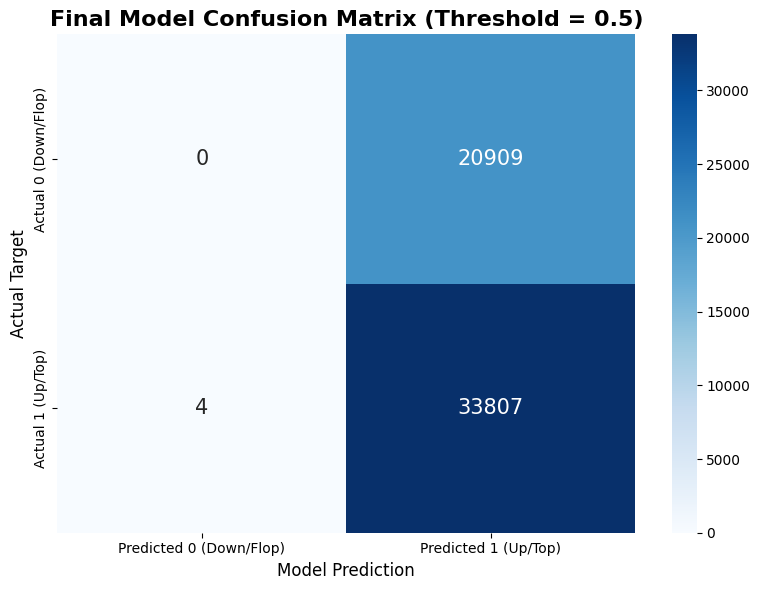

[최종 모델 분류 성능 지표 (Classification Metrics)]
총 평가 데이터: 54720 개
Accuracy  (정확도): 0.6178  <- 전체 중 맞춘 비율
Precision (정밀도): 0.6179  <- '오른다'고 예측한 것 중 진짜 오른 비율 (제일 중요!)
Recall    (재현율): 0.9999  <- 실제 오른 것 중 모델이 찾아낸 비율
F1-Score  (F1점수): 0.7638  <- 정밀도와 재현율의 조화 평균
------------------------------------------------------------
                precision    recall  f1-score   support

Class 0 (Down)       0.00      0.00      0.00     20909
  Class 1 (Up)       0.62      1.00      0.76     33811

      accuracy                           0.62     54720
     macro avg       0.31      0.50      0.38     54720
  weighted avg       0.38      0.62      0.47     54720



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score

print("[추가 분석] 최종 모델의 분류 성능 평가 (Confusion Matrix & F1-Score)...\n")

# 1. 평가용 데이터 준비 (결측치 제거)
eval_df = total_test_results.dropna(subset=['predict_prob', 'target']).copy()

# 2. 예측 클래스 생성 (기본 임계값 0.5 적용)
# 모델의 예측 확률이 50%(0.5) 이상이면 1(상회), 미만이면 0(하회)으로 판정
THRESHOLD = 0.5
eval_df['pred_class'] = (eval_df['predict_prob'] >= THRESHOLD).astype(int)

y_true = eval_df['target']
y_pred = eval_df['pred_class']

# 3. 혼동 행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_true, y_pred)

# 4. 핵심 성능 지표 계산
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# 5. 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 15},
            xticklabels=['Predicted 0 (Down/Flop)', 'Predicted 1 (Up/Top)'],
            yticklabels=['Actual 0 (Down/Flop)', 'Actual 1 (Up/Top)'])

plt.title(f'Final Model Confusion Matrix (Threshold = {THRESHOLD})', fontsize=16, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('Actual Target', fontsize=12)
plt.tight_layout()
plt.show()

# 6. 결과 요약 출력
print("============================================================")
print("[최종 모델 분류 성능 지표 (Classification Metrics)]")
print("============================================================")
print(f"총 평가 데이터: {len(eval_df)} 개")
print(f"Accuracy  (정확도): {acc:.4f}  <- 전체 중 맞춘 비율")
print(f"Precision (정밀도): {prec:.4f}  <- '오른다'고 예측한 것 중 진짜 오른 비율 (제일 중요!)")
print(f"Recall    (재현율): {rec:.4f}  <- 실제 오른 것 중 모델이 찾아낸 비율")
print(f"F1-Score  (F1점수): {f1:.4f}  <- 정밀도와 재현율의 조화 평균")
print("------------------------------------------------------------")
print(classification_report(y_true, y_pred, target_names=['Class 0 (Down)', 'Class 1 (Up)']))
print("============================================================")


# GG